# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.common.utils import get_root_directory
from src.visualisation.plotter import Plotter
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import calendar
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
import gensim
from gensim.utils import simple_preprocess

## Google News Headlines

In [8]:
root_dir = get_root_directory()
plotter = Plotter(root_dir)
processed_gn = pd.read_csv(f"{root_dir}\data\processed\Google_News_Headlines_data\google_news_headlines_data.csv")

In [3]:
processed_gn

,Date,News Headline,Publisher
0,2017-11-09,Hong Kong Fintech Innovation Lab Led with Bloc...,Forbes
1,2017-11-09,Decentralized Electricity Could be Blockchain’...,Cointelegraph
2,2017-11-09,Ethereum cryptocurrency value dropped due to w...,Inquirer.net
3,2017-11-09,Ambrosus: Digitalising the Global Trade with B...,Open Access Government
4,2017-11-09,Exchange Comparison: Kraken vs Bitstamp - Coin...,CoinCentral
...,...,...,...
156569,2024-08-11,Monero Price Prediction 2024-2030: A Good Inve...,Cryptopolitan
156570,2024-08-11,Could Bitcoin Crash? Celsius Slaps Tether with...,Cryptonews
156571,2024-08-11,SEC Addresses Final Court Ruling in Ripple Cas...,Bitcoin.com News
156572,2024-08-11,Best Top 5 Crypto to Buy (Short List) / X100 M...,Crypto News Flash


In [4]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Date           156574 non-null  object
 1   News Headline  156574 non-null  object
 2   Publisher      156574 non-null  object
dtypes: object(3)
memory usage: 3.6+ MB


In [5]:
processed_gn = processed_gn.astype('string')
processed_gn['Date'] = pd.to_datetime(processed_gn['Date'])

In [6]:
processed_gn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156574 entries, 0 to 156573
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           156574 non-null  datetime64[ns]
 1   News Headline  156574 non-null  string        
 2   Publisher      156574 non-null  string        
dtypes: datetime64[ns](1), string(2)
memory usage: 3.6 MB


In [7]:
publishers = list(processed_gn['Publisher'].unique()) 

In [8]:
sorted(publishers)

['#NAME?',
 '- Disrupt Africa',
 '032c',
 '06880',
 '1.00E+09',
 '1010 WINS',
 '106.9 KROC',
 '107.180.56.147',
 '10TV',
 '11Alive.com WXIA',
 '11Onze',
 '12news.com KPNX',
 '1337 Games',
 '13WHAM-TV',
 '13WMAZ.com',
 '13newsnow.com WVEC',
 '150sec',
 '15min',
 '1819 News',
 '1E9',
 '1Lurer',
 '1News',
 '2 News Oklahoma KJRH Tulsa',
 '218 News',
 '225 Baton Rouge',
 '24',
 '24 News HD',
 '24-7 Press Release',
 '24/7 Wall St.',
 '25 News KXXV and KRHD',
 '263chat.com',
 '360 Magazine',
 '365 Retail',
 '368.media',
 '36NG',
 '3BL Media',
 '3D Printing Industry',
 '3DPrint.com',
 '3Dnatives',
 '3FM',
 '3VB',
 '3news',
 '411mania.com',
 '48 Hills',
 '5 Dariya News',
 '5280 | The Denver Magazine',
 '69News WFMZ-TV',
 '6Sqft',
 '7NEWS',
 '8 Days',
 '80.lv',
 '90.5 WESA',
 '96FM Perth',
 '97.3 The Dawg',
 '97.9 WGRD',
 '99.co',
 '99Bitcoins',
 '99signals',
 '9News',
 '9News.com KUSA',
 '9to5Google',
 '9to5Mac',
 'A Journal of Musical Things',
 'A Wealth of Common Sense',
 'A&O Shearman',
 'A3

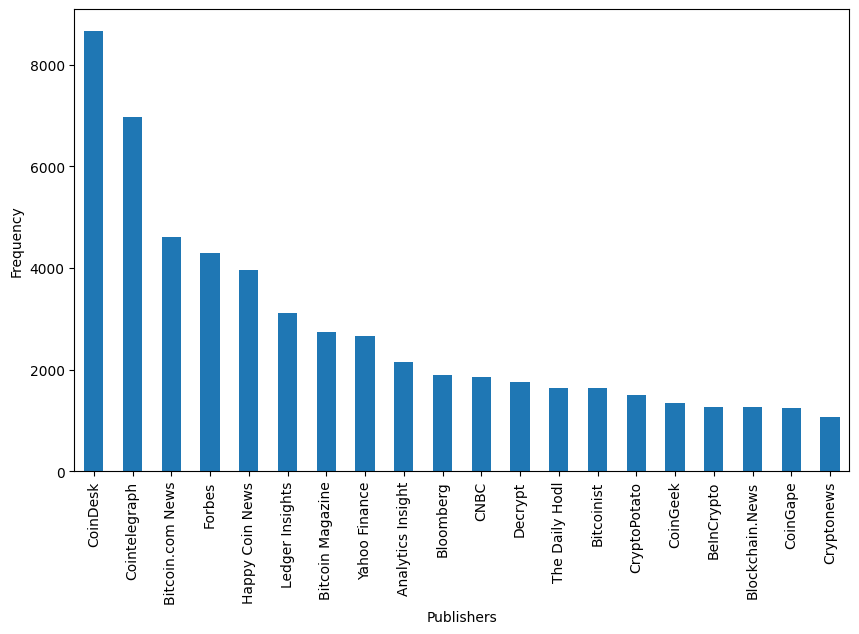

In [9]:
n = 20
top_n = processed_gn['Publisher'].value_counts().nlargest(n)
plotter = Plotter(root_dir)
plotter.plot_barchart(df=top_n, x="Publishers", y="Frequency")

In [10]:
len(processed_gn['News Headline'].unique())

156574

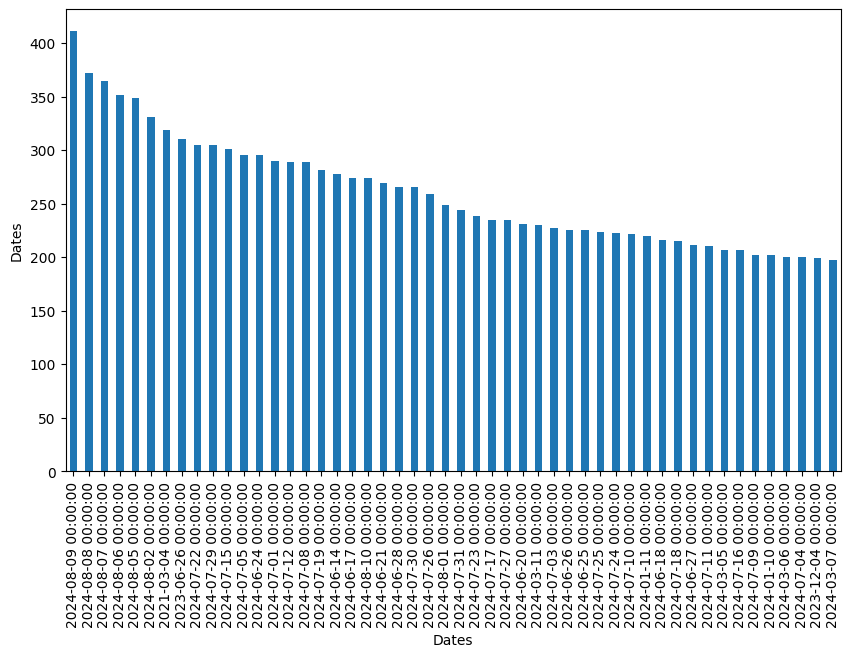

In [11]:
n = 50
top_n = processed_gn['Date'].value_counts().nlargest(n)
plotter.plot_barchart(df=top_n, x="Dates", y="Dates")

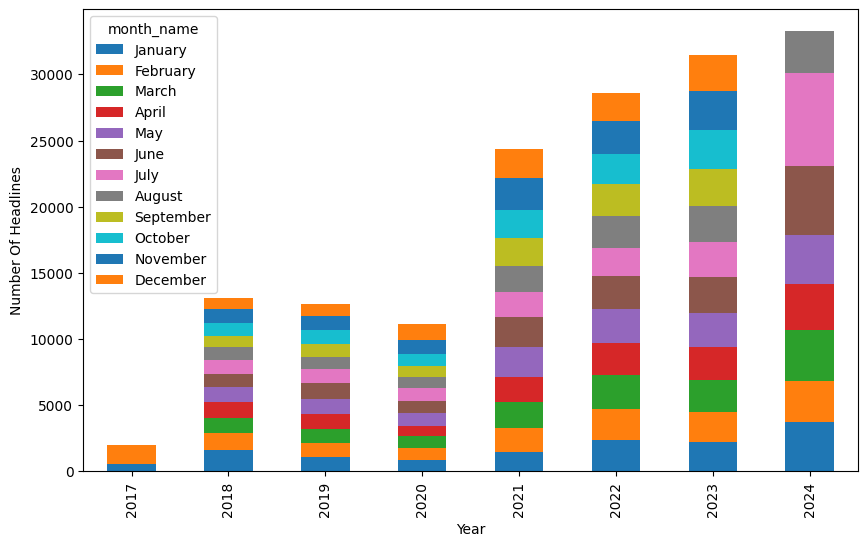

In [12]:
processed_gn['year'] = processed_gn['Date'].dt.year
processed_gn['month'] =processed_gn['Date'].dt.month

# Create a new column with month names (for plotting)
processed_gn['month_name'] = processed_gn['Date'].dt.month_name()

# Group by year and month name, then count the number of headlines
grouped = processed_gn.groupby(['year', 'month_name']).size().unstack(fill_value=0)

# Reorder the columns to follow the calendar month order
months_order = list(calendar.month_name)[1:]  # list from 'January' to 'December'
grouped = grouped.reindex(columns=months_order, fill_value=0)
grouped

plotter.plot_barchart(df=grouped, x="year", y="Number of Headlines", stacked=True)

# Plot the stacked bar chart
# ax = grouped.plot(kind='bar', stacked=True, figsize=(10, 6))

# Set plot labels and title
# plt.xlabel('Year')
# plt.ylabel('Number of Headlines')
# plt.title('Number of Headlines per Year, Split by Month')

# # Place the legend outside the plot area for better visibility
# plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
# plt.show()

In [13]:
plotter.save_graph()

In [14]:
processed_gn['length'] = processed_gn['News Headline'].apply(lambda x: len(x.split()))

In [15]:
extreme = list(processed_gn['News Headline'][processed_gn['length']==46])

In [16]:
processed_gn

,Date,News Headline,Publisher,year,month,month_name,length
0,2017-11-09,Hong Kong Fintech Innovation Lab Led with Bloc...,Forbes,2017,11,November,12
1,2017-11-09,Decentralized Electricity Could be Blockchain’...,Cointelegraph,2017,11,November,9
2,2017-11-09,Ethereum cryptocurrency value dropped due to w...,Inquirer.net,2017,11,November,11
3,2017-11-09,Ambrosus: Digitalising the Global Trade with B...,Open Access Government,2017,11,November,11
4,2017-11-09,Exchange Comparison: Kraken vs Bitstamp - Coin...,CoinCentral,2017,11,November,7
...,...,...,...,...,...,...,...
156569,2024-08-11,Monero Price Prediction 2024-2030: A Good Inve...,Cryptopolitan,2024,8,August,9
156570,2024-08-11,Could Bitcoin Crash? Celsius Slaps Tether with...,Cryptonews,2024,8,August,14
156571,2024-08-11,SEC Addresses Final Court Ruling in Ripple Cas...,Bitcoin.com News,2024,8,August,14
156572,2024-08-11,Best Top 5 Crypto to Buy (Short List) / X100 M...,Crypto News Flash,2024,8,August,18


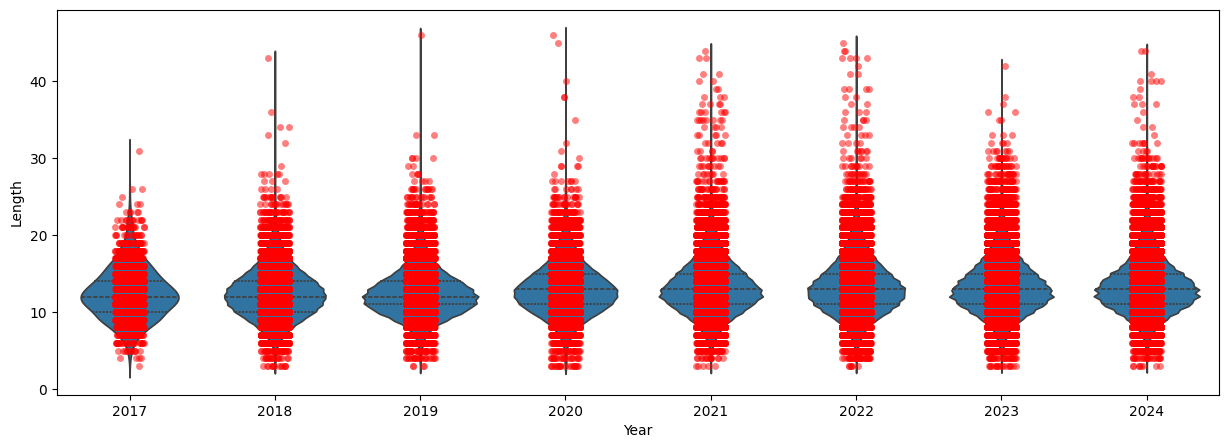

In [17]:
plotter.plot_violin_plot(df=processed_gn, x="year", y="length", stripplot = True, figsize=(15,5))

In [18]:
# Initialize NLTK components
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words("english"))

def generate_clean_tokens(text):
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\b\w{21,}\b', '', text)
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rajdh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
processed_gn['cleaned'] = processed_gn['News Headline'].apply(lambda x: generate_clean_tokens(x))

In [20]:
processed_gn

,Date,News Headline,Publisher,year,month,month_name,length,cleaned
0,2017-11-09,Hong Kong Fintech Innovation Lab Led with Bloc...,Forbes,2017,11,November,12,"[hong, kong, fintech, innovation, lab, led, bl..."
1,2017-11-09,Decentralized Electricity Could be Blockchain’...,Cointelegraph,2017,11,November,9,"[decentralized, electricity, could, blockchain..."
2,2017-11-09,Ethereum cryptocurrency value dropped due to w...,Inquirer.net,2017,11,November,11,"[ethereum, cryptocurrency, value, dropped, due..."
3,2017-11-09,Ambrosus: Digitalising the Global Trade with B...,Open Access Government,2017,11,November,11,"[ambrosus, digitalising, global, trade, blockc..."
4,2017-11-09,Exchange Comparison: Kraken vs Bitstamp - Coin...,CoinCentral,2017,11,November,7,"[exchange, comparison, kraken, v, bitstamp, co..."
...,...,...,...,...,...,...,...,...
156569,2024-08-11,Monero Price Prediction 2024-2030: A Good Inve...,Cryptopolitan,2024,8,August,9,"[monero, price, prediction, good, investment, ..."
156570,2024-08-11,Could Bitcoin Crash? Celsius Slaps Tether with...,Cryptonews,2024,8,August,14,"[could, bitcoin, crash, celsius, slap, tether,..."
156571,2024-08-11,SEC Addresses Final Court Ruling in Ripple Cas...,Bitcoin.com News,2024,8,August,14,"[sec, address, final, court, ruling, ripple, c..."
156572,2024-08-11,Best Top 5 Crypto to Buy (Short List) / X100 M...,Crypto News Flash,2024,8,August,18,"[best, top, crypto, buy, short, list, x, moons..."


In [21]:
list(processed_gn['cleaned'])

[['hong',
  'kong',
  'fintech',
  'innovation',
  'lab',
  'led',
  'blockchain',
  'ai',
  'forbes'],
 ['decentralized',
  'electricity',
  'could',
  'blockchains',
  'trojan',
  'horse',
  'cointelegraph'],
 ['ethereum',
  'cryptocurrency',
  'value',
  'dropped',
  'due',
  'wallet',
  'security',
  'vulnerability',
  'inquirernet'],
 ['ambrosus',
  'digitalising',
  'global',
  'trade',
  'blockchain',
  'open',
  'access',
  'government'],
 ['exchange', 'comparison', 'kraken', 'v', 'bitstamp', 'coincentral'],
 ['ethereum',
  'creator',
  'wonder',
  'whether',
  'currency',
  'scarcer',
  'economic',
  'time'],
 ['cryptography', 'global', 'health', 'harvard', 'medical', 'school'],
 ['tiny', 'house', 'heated', 'bitcoin', 'mining', 'archivecurbedcom'],
 ['code', 'bug', 'freeze', 'ethereum', 'cryptocash', 'bbccom'],
 ['new', 'blockchain', 'project', 'last', 'year', 'still', 'active', 'cnbc'],
 ['irrational',
  'exuberance',
  'icos',
  'tech',
  'stay',
  'ethereum',
  'cofounder',

In [33]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import CoherenceModel
dictionary= Dictionary(list(processed_gn['cleaned'])) 
bow_corpus = [dictionary.doc2bow(doc) for doc in list(processed_gn['cleaned'])]


# def calculate_coherence_score(corpus, dictionary, texts, num_topics):
#     lda_model = LdaModel(corpus=corpus,
#                          id2word=dictionary,
#                          num_topics=num_topics,
#                          random_state=42,
#                          passes=10)
#     coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
#     coherence_score = coherence_model_lda.get_coherence()
#     perplexity = lda_model.log_perplexity(corpus)
#     return coherence_score, perplexity

# # Lists to store data for plotting
# num_topics_list = []
# coherence_score_list = []
# log_perplexity = []

# # Iterate over different numbers of topics
# min_topics = 1
# max_topics = 10
# step = 1
# for num_topics in range(min_topics, max_topics + 1, step):
#     coherence_score, perplexity = calculate_coherence_score(bow_corpus, dictionary, list(processed_gn['cleaned']), num_topics)
#     print(f"Number of topics: {num_topics}, Coherence Score: {coherence_score}")
#     num_topics_list.append(num_topics)
#     coherence_score_list.append(coherence_score)
#     log_perplexity.append(perplexity)

# # Plotting coherence score vs. number of topics
# plt.plot(num_topics_list, coherence_score_list)
# plt.plot(num_topics_list, log_perplexity)
# plt.xlabel("Number of Topics")
# plt.ylabel("Coherence Score")
# plt.title("Coherence Score vs. Number of Topics")
# plt.show()

# # Find the best number of topics based on the maximum coherence score
# best_num_topics = num_topics_list[coherence_score_list.index(max(coherence_score_list))]
# best_coherence_score = max(coherence_score_list)
# print(f"Best number of topics: {best_num_topics}, Best coherence score: {best_coherence_score}")


# This call will construct and fit (train) the LDA model:
lda_model =  LdaModel(bow_corpus, 
                      num_topics=5, 
                      id2word=dictionary,                                    
                      passes=10,
                    )

def get_lda_topics(model, num_topics, top_n_words):
     word_dict = []
     for i in range(num_topics):
         word_dict.extend([i[0] for i in model.show_topic(i, topn = top_n_words)])
     return word_dict
x = get_lda_topics(lda_model,5,10)


## ETH Data

In [5]:
import numpy as np
etherscan = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_etherscan.csv")
bic_eth = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_bitinfocharts.csv")
ol_eth = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_oklink.csv")

In [6]:
etherscan.replace(0, np.nan, inplace=True)
bic_eth.replace(0, np.nan, inplace=True)
ol_eth.replace(0, np.nan, inplace=True)

In [24]:
etherscan.drop(columns=['BlockDifficulty','BlockReward', 'NetworkHash','Uncles'], inplace=True)
bic_eth.drop(columns=['Difficulty','Hashrate'], inplace=True)
ol_eth.drop(columns=['ETH average computing power of the entire network','ETH mining difficulty'], inplace=True)

In [25]:
etherscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        2467 non-null   object 
 1   Open                        2467 non-null   float64
 2   High                        2467 non-null   float64
 3   Low                         2467 non-null   float64
 4   Close                       2467 non-null   float64
 5   Adj Close                   2467 non-null   float64
 6   Volume                      2467 non-null   int64  
 7   AddressCount                2467 non-null   int64  
 8   AverageDailyTransactionFee  2467 non-null   float64
 9   AvgGasPrice                 2467 non-null   int64  
 10  BlockCountRewards           2467 non-null   int64  
 11  BlockSize                   2467 non-null   int64  
 12  BlockTime                   2467 non-null   float64
 13  DailyActiveEthAddress       2467 

In [26]:
bic_eth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2393 non-null   float64
 9   Active Addressses  2457 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 192.9+ KB


In [27]:
ol_eth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 19 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Date                                           2467 non-null   object 
 1   Open                                           2467 non-null   float64
 2   High                                           2467 non-null   float64
 3   Low                                            2467 non-null   float64
 4   Close                                          2467 non-null   float64
 5   Adj Close                                      2467 non-null   float64
 6   Volume                                         2467 non-null   int64  
 7   ETH Gas price                                  2467 non-null   float64
 8   ETH total supply                               2447 non-null   float64
 9   ETH daily transaction fee                      2467 

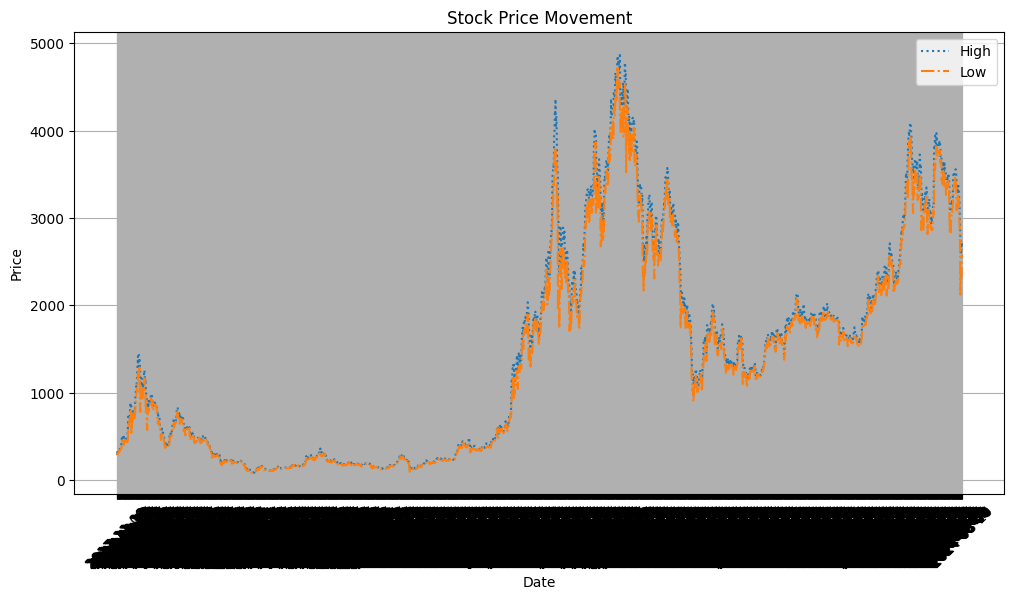

In [64]:
# etherscan.set_index('Date', inplace=True)

# Plot the data
plt.figure(figsize=(12, 6))
# plt.plot(etherscan.index, etherscan['Open'], label='Open', linestyle='dashed', marker='o')
plt.plot(etherscan.index, etherscan['High'], label='High', linestyle='dotted')
plt.plot(etherscan.index, etherscan['Low'], label='Low', linestyle='dashdot')
# plt.plot(etherscan.index, etherscan['Close'], label='Close', linestyle='solid', marker='d')

# Formatting the graph
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Price Movement')
plt.legend()
plt.xticks(rotation=45)
plt.grid()

# Show the plot
plt.show()

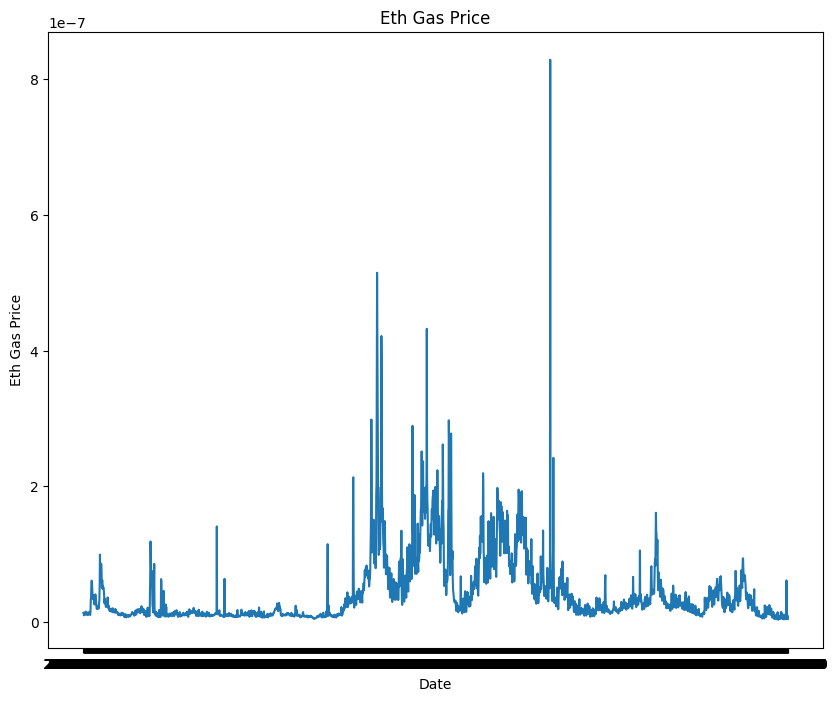

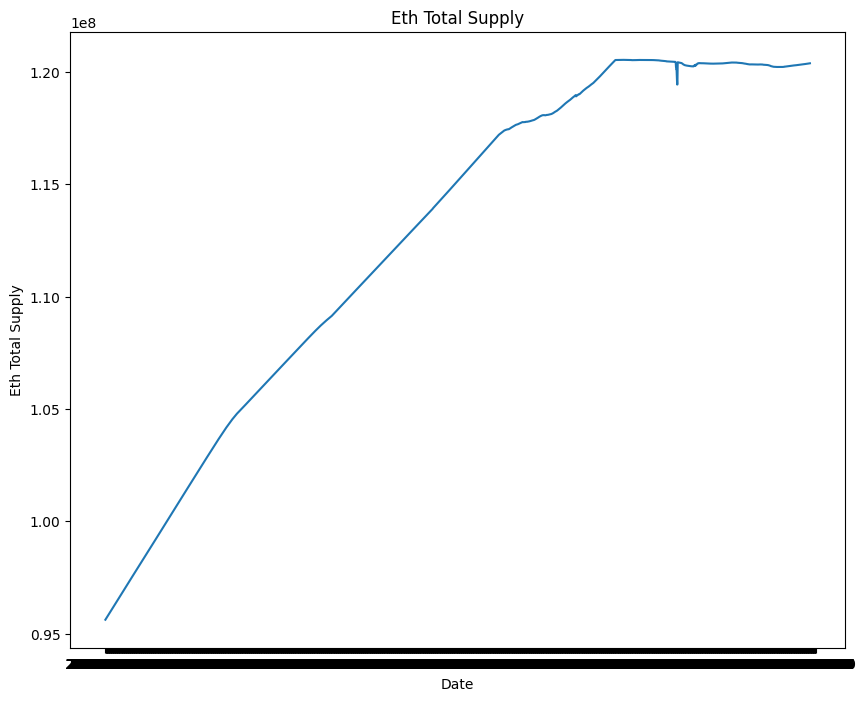

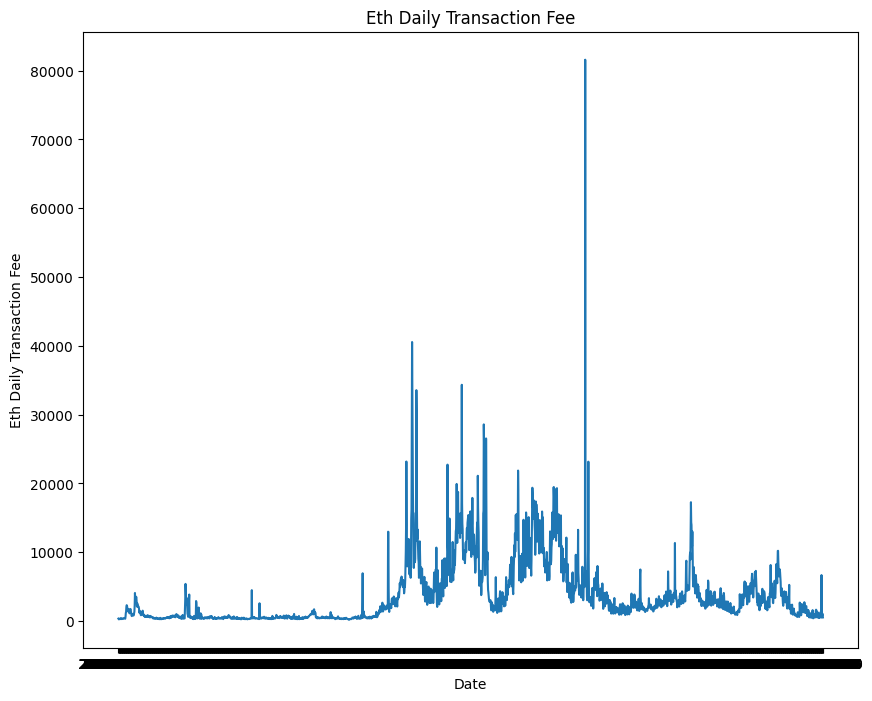

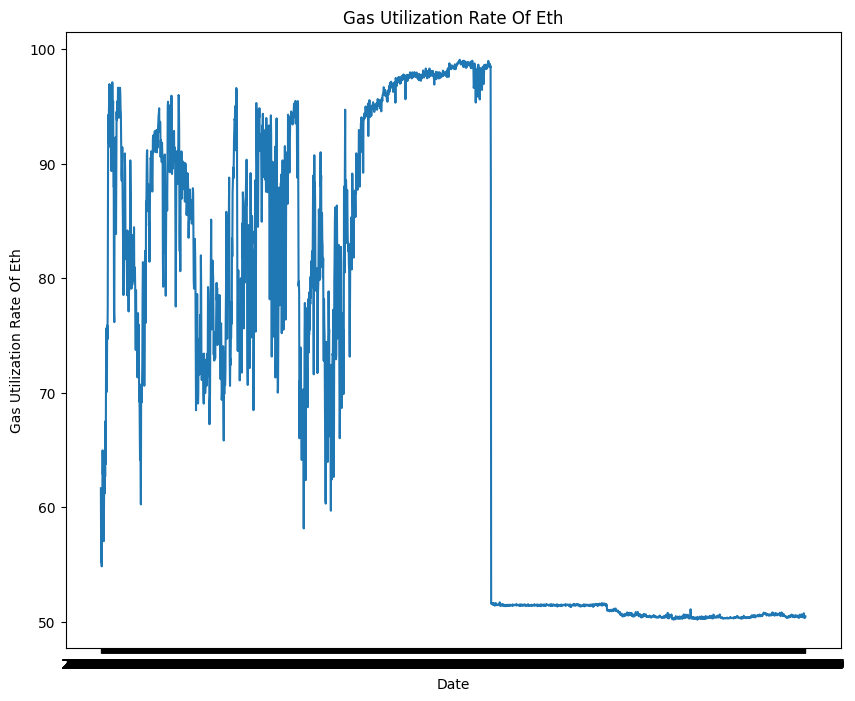

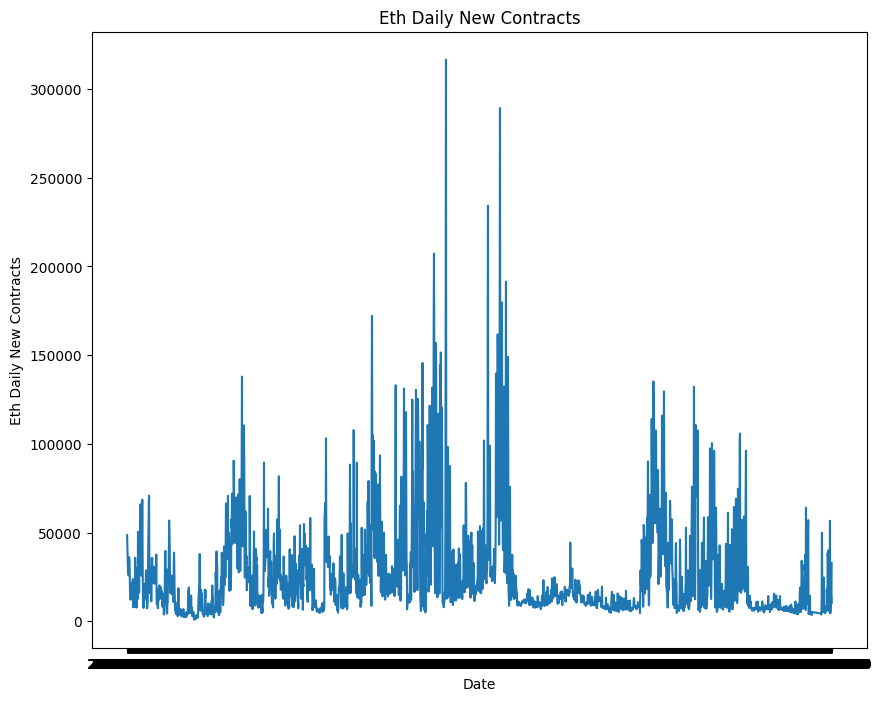

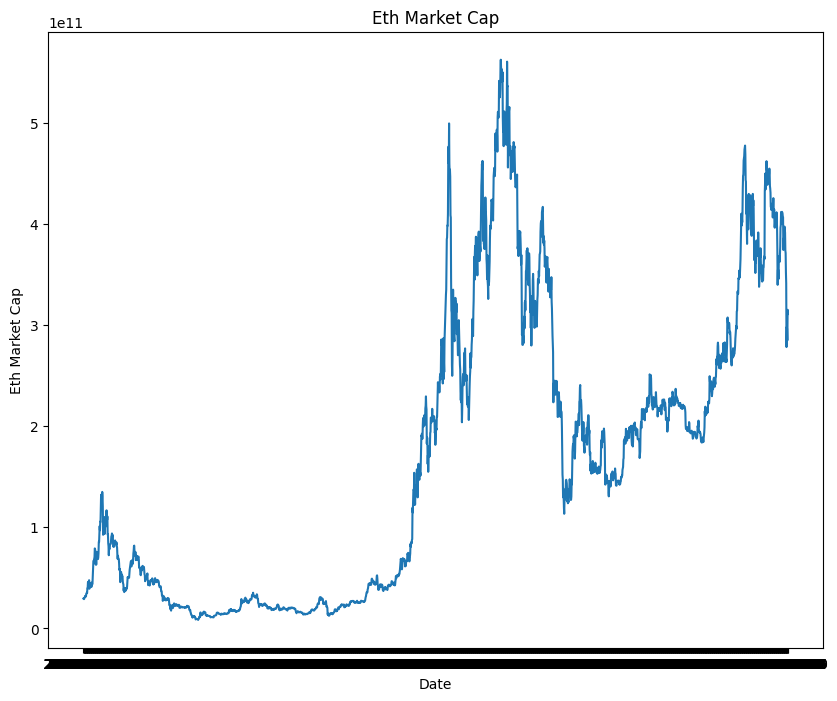

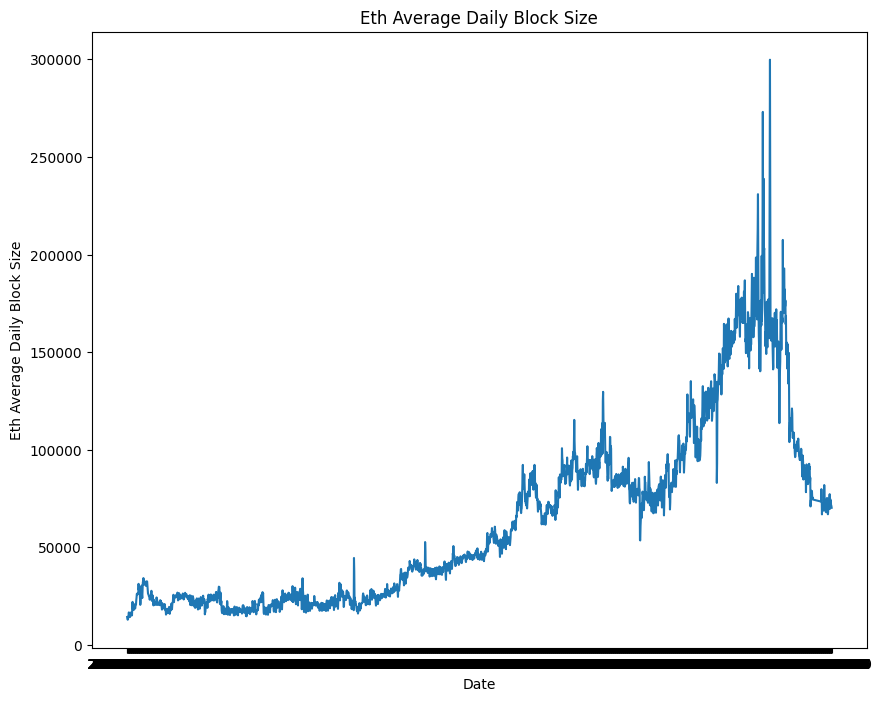

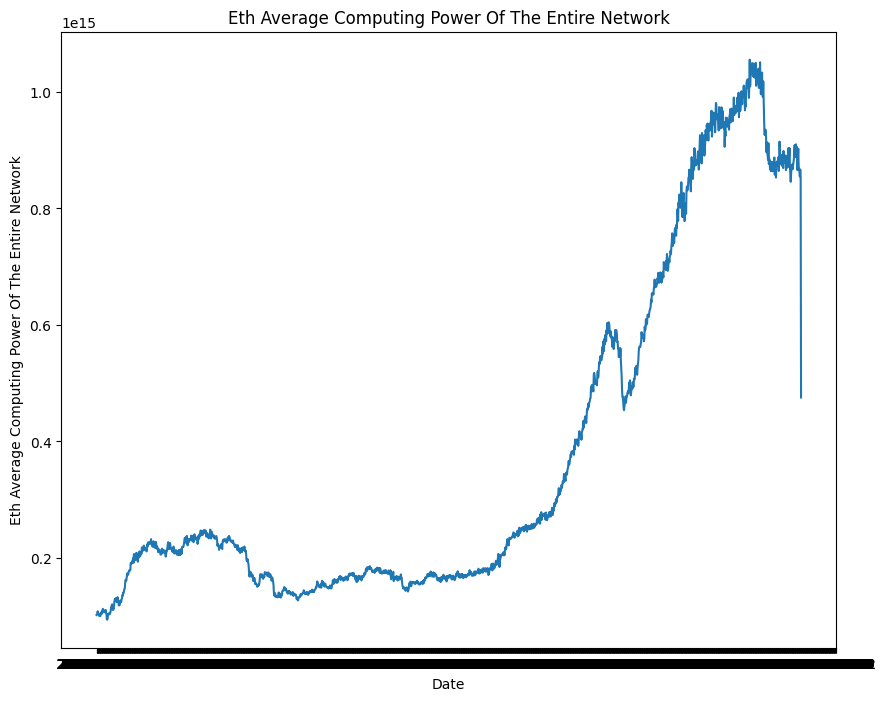

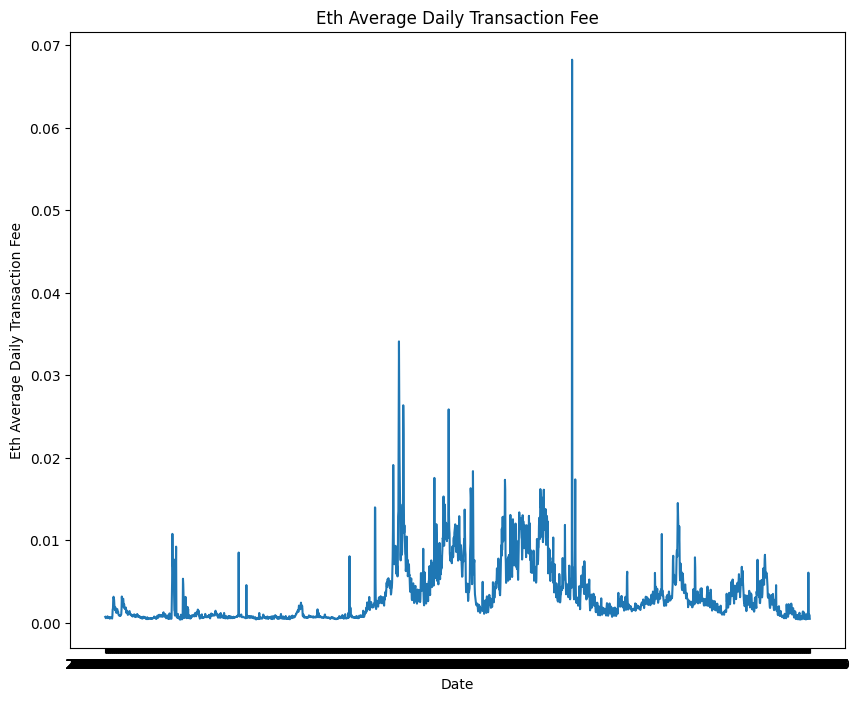

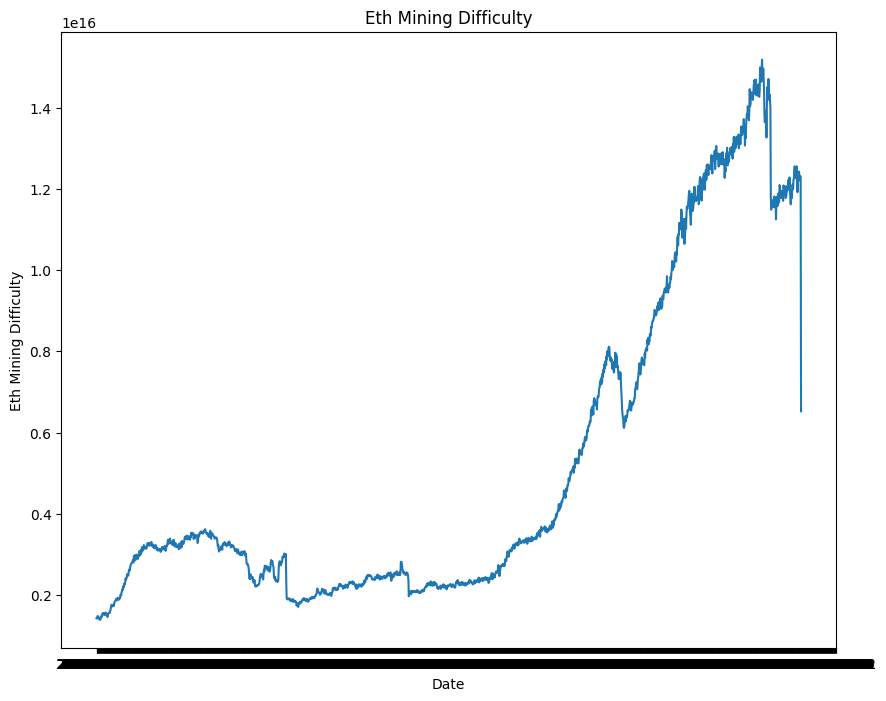

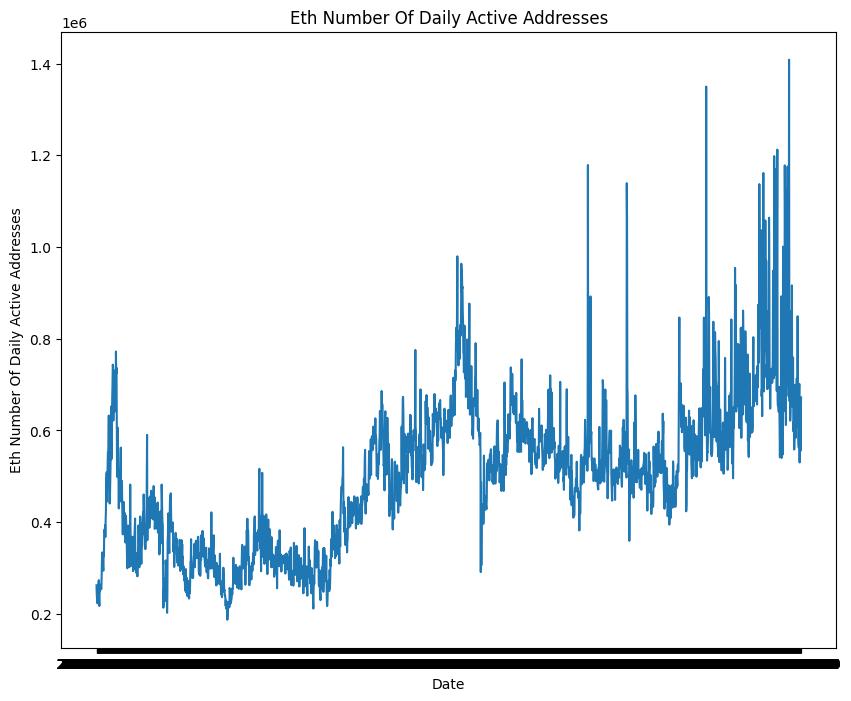

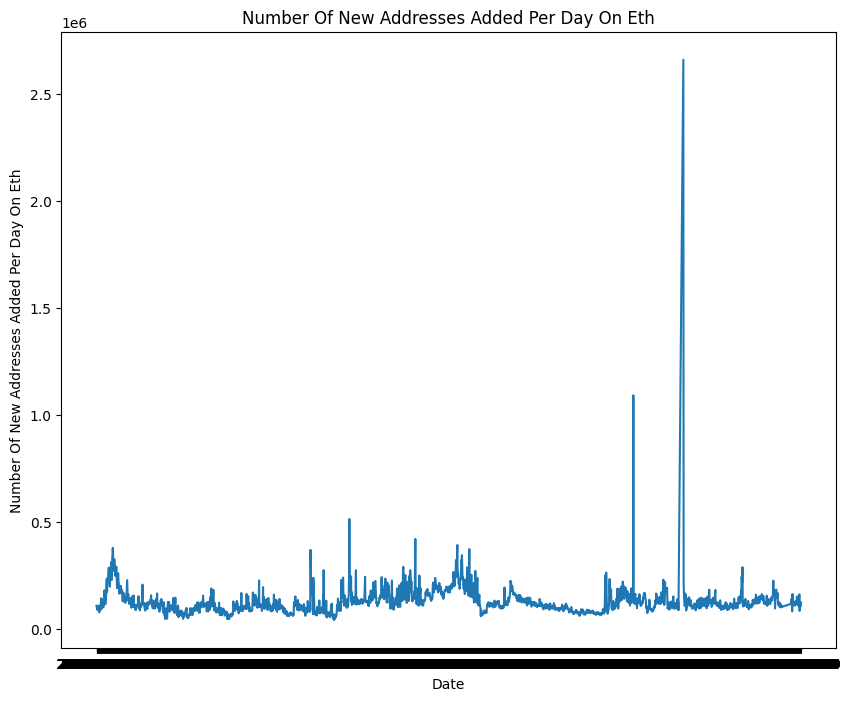

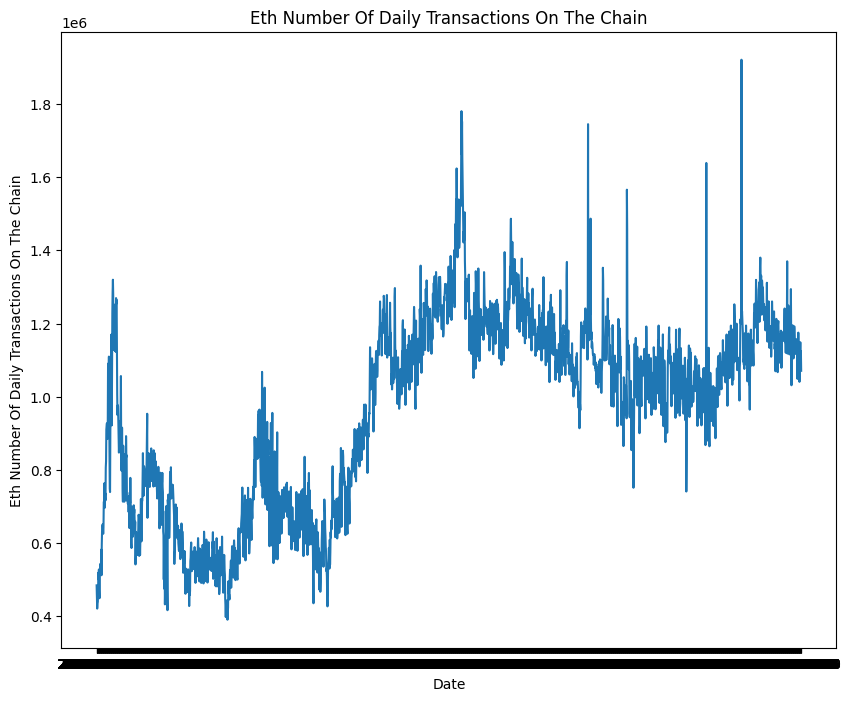

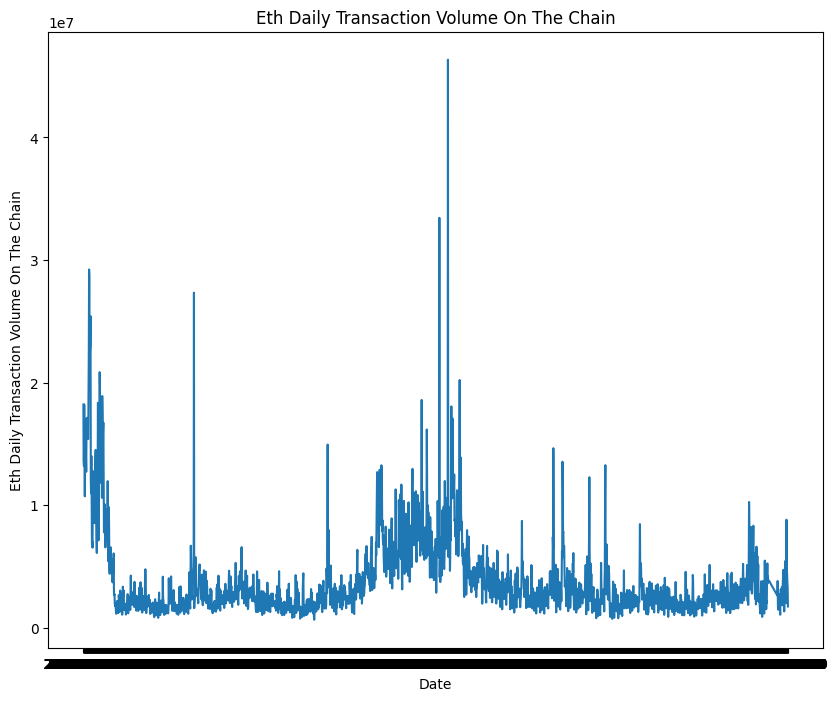

In [11]:
for i, column in enumerate(list(ol_eth.columns)):
    if i >=7:
        plotter.plot_lineplot(df=ol_eth, x="Date", y=column, title=column)
        plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\ETH\\oklink")

### bitinfocharts

In [14]:
bic = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_bitinfocharts.csv")

In [16]:
bic.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Transactions,Block Size,Difficulty,Hashrate,Active Addressses
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984,467172.0,13929.0,1.420593e+15,1.141152e+14,278497.0
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984,457427.0,13413.0,1.429592e+15,1.157639e+14,274759.0
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992,394378.0,12665.0,1.437744e+15,1.157176e+14,235263.0
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936,434380.0,13233.0,1.487331e+15,1.182550e+14,274397.0
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984,443176.0,14443.0,1.456779e+15,1.174600e+14,261901.0


In [17]:
bic.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,Transactions,Block Size,Difficulty,Hashrate,Active Addressses
2462,2024-08-06,2417.269775,2553.581055,2416.527100,2458.723877,2458.723877,26041995921,1130468.0,74753.0,NaN,NaN,641101.0
2463,2024-08-07,2458.989014,2551.560791,2312.168701,2336.589355,2336.589355,24264218606,1123175.0,73440.0,NaN,NaN,631524.0
2464,2024-08-08,2336.915039,2721.954590,2322.529541,2683.352783,2683.352783,23468291180,1097066.0,71469.0,NaN,NaN,593976.0
2465,2024-08-09,2683.719971,2706.451172,2555.229492,2599.598633,2599.598633,17907141655,1100553.0,72305.0,NaN,NaN,608784.0
2466,2024-08-10,2599.780518,2641.628418,2584.745117,2616.107910,2616.107910,12015107072,1051563.0,66100.0,NaN,NaN,642393.0


In [18]:
bic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2393 non-null   float64
 9   Difficulty         1772 non-null   float64
 10  Hashrate           1772 non-null   float64
 11  Active Addressses  2457 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


### oklink

In [19]:
ol = pd.read_csv(f"{root_dir}\data\processed\ETH_data\ETH_oklink.csv")

In [20]:
ol.head()

,Date,Open,High,Low,Close,Adj Close,Volume,ETH Gas price,ETH total supply,ETH daily transaction fee,...,ETH daily new contracts,ETH market cap,ETH average daily block size,ETH average computing power of the entire network,ETH average daily transaction fee,ETH mining difficulty,ETH number of daily active addresses,Number of new addresses added per day on ETH,ETH number of daily transactions on the chain,ETH daily transaction volume on the chain
0,2017-11-09,308.644989,329.451996,307.056000,320.884003,320.884003,893249984,1.372173e-08,9.562157e+07,350.56,...,48579,2.954960e+10,14340.615883,1.020832e+14,0.000723,1.429281e+15,262399,107924.0,484538,1.820082e+07
1,2017-11-10,320.670990,324.717987,294.541992,299.252991,299.252991,885985984,1.295271e-08,9.564192e+07,299.08,...,41795,2.923552e+10,13392.912143,1.025360e+14,0.000668,1.422936e+15,240748,100455.0,447845,1.367588e+07
2,2017-11-11,298.585999,319.453003,298.191986,314.681000,314.681000,842300992,1.008393e-08,9.566232e+07,235.87,...,34364,2.893212e+10,12942.124364,1.045174e+14,0.000560,1.435331e+15,231360,90339.0,421015,1.320412e+07
3,2017-11-12,314.690002,319.153015,298.513000,307.907990,307.907990,1613479936,1.260724e-08,9.568283e+07,292.63,...,27913,2.939015e+10,13245.320964,1.085052e+14,0.000672,1.485859e+15,223189,95159.0,435550,1.820865e+07
4,2017-11-13,307.024994,328.415009,307.024994,316.716003,316.716003,1041889984,1.270490e-08,9.570294e+07,306.10,...,30092,3.030491e+10,14180.349026,1.039709e+14,0.000696,1.458006e+15,231483,92372.0,439701,1.398042e+07


In [21]:
ol.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,ETH Gas price,ETH total supply,ETH daily transaction fee,...,ETH daily new contracts,ETH market cap,ETH average daily block size,ETH average computing power of the entire network,ETH average daily transaction fee,ETH mining difficulty,ETH number of daily active addresses,Number of new addresses added per day on ETH,ETH number of daily transactions on the chain,ETH daily transaction volume on the chain
2462,2024-08-06,2417.269775,2553.581055,2416.527100,2458.723877,2458.723877,26041995921,9.453782e-09,NaN,1022.77,...,5735,2.981928e+11,74528.659269,0.0,0.000919,0.0,635359,110532.0,1112869,4.661119e+06
2463,2024-08-07,2458.989014,2551.560791,2312.168701,2336.589355,2336.589355,24264218606,6.973131e-09,NaN,756.51,...,10977,2.963320e+11,73692.019118,0.0,0.000659,0.0,663668,104023.0,1148780,4.452269e+06
2464,2024-08-08,2336.915039,2721.954590,2322.529541,2683.352783,2683.352783,23468291180,1.007157e-08,NaN,1091.81,...,14660,2.848834e+11,71404.627631,0.0,0.000997,0.0,555190,104189.0,1095614,3.680258e+06
2465,2024-08-09,2683.719971,2706.451172,2555.229492,2599.598633,2599.598633,17907141655,8.435117e-09,NaN,914.21,...,9903,3.151378e+11,71253.455052,0.0,0.000813,0.0,606483,107450.0,1124339,3.334025e+06
2466,2024-08-10,2599.780518,2641.628418,2584.745117,2616.107910,2616.107910,12015107072,4.794635e-09,NaN,520.24,...,32866,3.109373e+11,70275.461635,0.0,0.000486,0.0,672189,123382.0,1070734,1.726620e+06


In [22]:
ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 21 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   ETH Gas price                                      2467 non-null   float64
 8   ETH total supply                                   2447 non-null   float64
 9   ETH dail

In [23]:
ol.replace(0, np.nan, inplace=True)

In [24]:
ol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 21 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   ETH Gas price                                      2467 non-null   float64
 8   ETH total supply                                   2447 non-null   float64
 9   ETH dail

In [25]:
ol.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,ETH Gas price,ETH total supply,ETH daily transaction fee,...,ETH daily new contracts,ETH market cap,ETH average daily block size,ETH average computing power of the entire network,ETH average daily transaction fee,ETH mining difficulty,ETH number of daily active addresses,Number of new addresses added per day on ETH,ETH number of daily transactions on the chain,ETH daily transaction volume on the chain
2462,2024-08-06,2417.269775,2553.581055,2416.527100,2458.723877,2458.723877,26041995921,9.453782e-09,NaN,1022.77,...,5735.0,2.981928e+11,74528.659269,NaN,0.000919,NaN,635359,110532.0,1112869,4.661119e+06
2463,2024-08-07,2458.989014,2551.560791,2312.168701,2336.589355,2336.589355,24264218606,6.973131e-09,NaN,756.51,...,10977.0,2.963320e+11,73692.019118,NaN,0.000659,NaN,663668,104023.0,1148780,4.452269e+06
2464,2024-08-08,2336.915039,2721.954590,2322.529541,2683.352783,2683.352783,23468291180,1.007157e-08,NaN,1091.81,...,14660.0,2.848834e+11,71404.627631,NaN,0.000997,NaN,555190,104189.0,1095614,3.680258e+06
2465,2024-08-09,2683.719971,2706.451172,2555.229492,2599.598633,2599.598633,17907141655,8.435117e-09,NaN,914.21,...,9903.0,3.151378e+11,71253.455052,NaN,0.000813,NaN,606483,107450.0,1124339,3.334025e+06
2466,2024-08-10,2599.780518,2641.628418,2584.745117,2616.107910,2616.107910,12015107072,4.794635e-09,NaN,520.24,...,32866.0,3.109373e+11,70275.461635,NaN,0.000486,NaN,672189,123382.0,1070734,1.726620e+06


In [2]:
for i, column in enumerate(list(ol_eth.columns)):
    if i >=7:
        plotter.plot_lineplot(df=ol_eth, x="Date", y=column, title=column)
        plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\ETH\\oklink")

NameError: name 'ol_eth' is not defined

In [41]:
ol_eth["USD Transaction daily fees"]= ((ol_eth["High"]+ol_eth["Low"])/2)*ol_eth["ETH average daily transaction fee"]

In [43]:
ol_eth["USD Transaction daily fees"].describe()

count    2467.000000
mean        6.478529
std        10.746970
min         0.051805
25%         0.235535
50%         2.514173
75%         7.128719
max       189.965378
Name: USD Transaction daily fees, dtype: float64

In [44]:
etherscan["AverageDailyTransactionFee"].describe()

count    2467.000000
mean        6.493308
std        10.839203
min         0.050000
25%         0.235000
50%         2.540000
75%         7.110000
max       200.060000
Name: AverageDailyTransactionFee, dtype: float64

In [45]:
etherscan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        2467 non-null   object 
 1   Open                        2467 non-null   float64
 2   High                        2467 non-null   float64
 3   Low                         2467 non-null   float64
 4   Close                       2467 non-null   float64
 5   Adj Close                   2467 non-null   float64
 6   Volume                      2467 non-null   int64  
 7   AddressCount                2467 non-null   int64  
 8   AverageDailyTransactionFee  2467 non-null   float64
 9   AvgGasPrice                 2467 non-null   int64  
 10  BlockCountRewards           2467 non-null   int64  
 11  BlockSize                   2467 non-null   int64  
 12  BlockTime                   2467 non-null   float64
 13  DailyActiveEthAddress       2467 

In [48]:
etherscan["AvgGasPriceUSD"] = (etherscan["AvgGasPrice"]*1e-9)

In [50]:
etherscan["AvgGasPriceUSD"].describe()

count    2467.000000
mean       44.825721
std        52.737598
min         3.497216
25%        14.470446
50%        24.472978
75%        53.785510
max       709.708436
Name: AvgGasPriceUSD, dtype: float64

In [52]:
ol_eth["ETH Gas price"].describe()

count    2.467000e+03
mean     4.301442e-08
std      5.168127e-08
min      3.568106e-09
25%      1.184773e-08
50%      2.311394e-08
75%      5.206231e-08
max      8.282577e-07
Name: ETH Gas price, dtype: float64

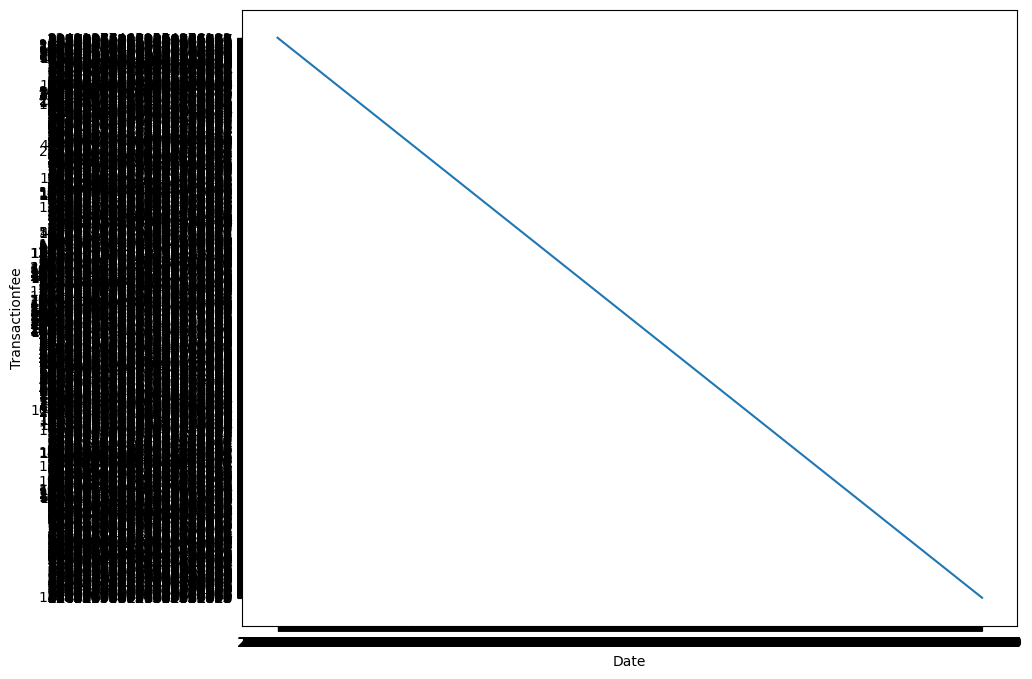

In [53]:
plotter.plot_lineplot(df=etherscan, x="Date", y="TransactionFee")

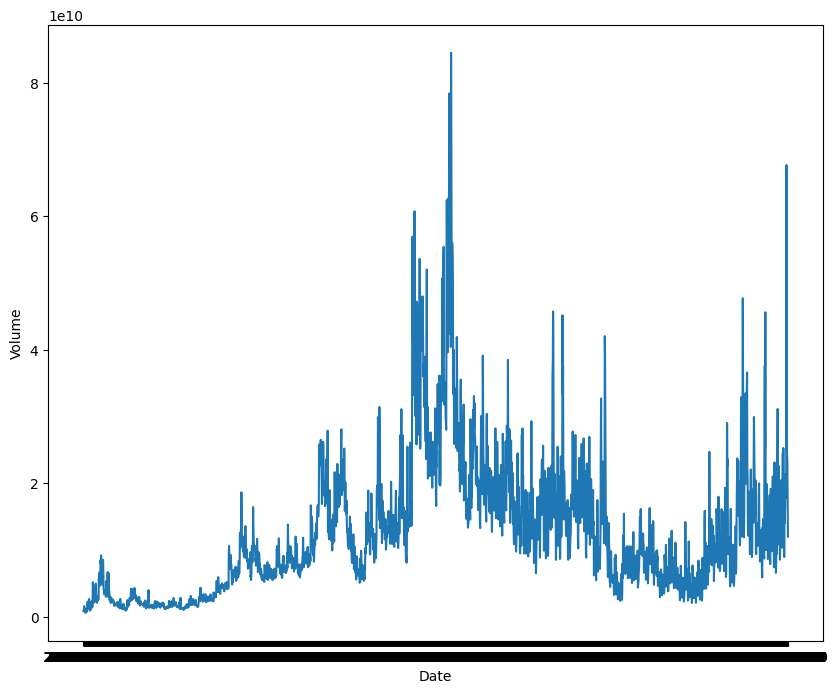

In [97]:
plotter.plot_lineplot(df=etherscan, x="Date", y="Volume")

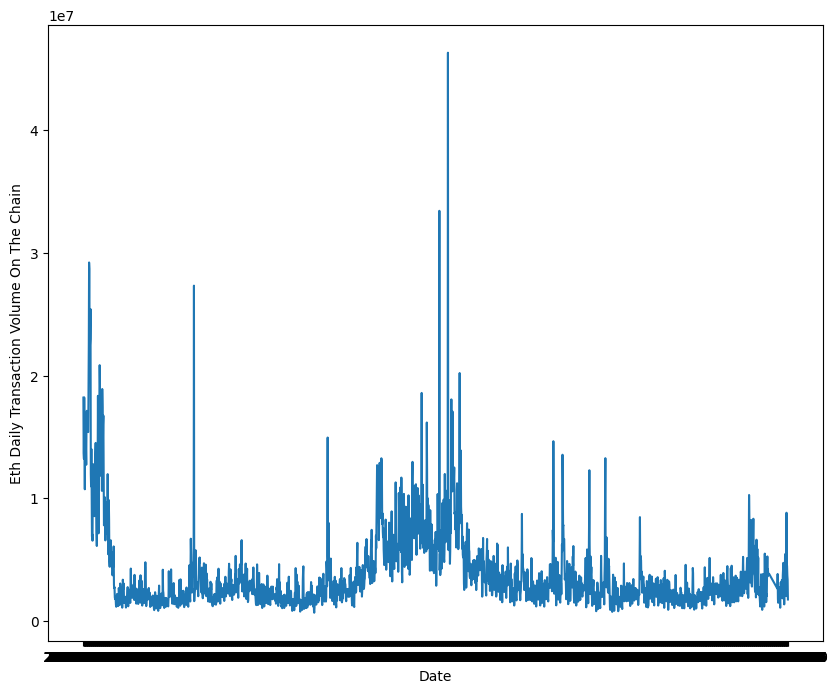

In [102]:
ol_eth["Volume USD"] = ol_eth["ETH daily transaction volume on the chain"]*((ol_eth["High"]+ol_eth["Low"])/2)
plotter.plot_lineplot(df=ol_eth, x="Date", y="ETH daily transaction volume on the chain")

## BTC

## bitinfocharts

In [12]:
bicbtc = pd.read_csv(f"{root_dir}\data\processed\BTC_data\BTC_bitinfocharts.csv")

In [42]:
bicbtc.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Transactions,Block Size,Difficulty,Hashrate,Active Addressses
0,2017-11-09,7446.830078,7446.830078,7101.520020,7143.580078,7143.580078,3226249984,341128.0,948715.0,1.452840e+12,1.044304e+19,820490.0
1,2017-11-10,7173.729980,7312.000000,6436.870117,6618.140137,6618.140137,5208249856,271625.0,957897.0,1.423367e+12,1.010747e+19,692632.0
2,2017-11-11,6618.609863,6873.149902,6204.220215,6357.600098,6357.600098,4908680192,194554.0,955967.0,1.364422e+12,6.857211e+18,536909.0
3,2017-11-12,6295.450195,6625.049805,5519.009766,5950.069824,5950.069824,8957349888,185886.0,961424.0,1.364422e+12,4.877691e+18,434508.0
4,2017-11-13,5938.250000,6811.189941,5844.290039,6559.490234,6559.490234,6263249920,309159.0,961228.0,1.364422e+12,7.975361e+18,766736.0


In [43]:
bicbtc.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,Transactions,Block Size,Difficulty,Hashrate,Active Addressses
2462,2024-08-06,53991.347656,57059.917969,53973.273438,56034.316406,56034.316406,49300484106,485033.0,781116.0,9.066650e+13,6.502267e+20,626324.0
2463,2024-08-07,56040.632812,57726.882812,54620.507812,55027.460938,55027.460938,41637562185,379975.0,783581.0,9.066650e+13,5.634361e+20,645017.0
2464,2024-08-08,55030.027344,62673.765625,54766.726562,61710.136719,61710.136719,45298472567,487270.0,792116.0,9.066650e+13,5.918414e+20,610636.0
2465,2024-08-09,61728.207031,61751.863281,59587.859375,60880.113281,60880.113281,33425553115,396289.0,716985.0,9.066650e+13,5.890192e+20,634633.0
2466,2024-08-10,60864.062500,61194.777344,60314.175781,60663.398438,60663.398438,22219999232,548648.0,795914.0,9.066650e+13,5.754545e+20,535207.0


In [44]:
bicbtc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2465 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


In [45]:
bicbtc.replace(0, np.nan, inplace=True)

In [46]:
bicbtc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2465 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


### oklink

In [13]:
ol_btc = pd.read_csv(f"{root_dir}\data\processed\BTC_data\BTC_oklink.csv")

In [81]:
ol_btc

,Date,Open,High,Low,Close,Adj Close,Volume,BTC total supply,BTC market cap,BTC average daily block size,BTC average computing power of the entire network,BTC average daily transaction fee,BTC mining difficulty,BTC number of daily active addresses,Number of new addresses added per day on BTC,BTC total addresses,BTC number of daily transactions on the chain,BTC full node data size,BTC daily transaction volume on the chain
0,2017-11-09,7446.830078,7446.830078,7101.520020,7143.580078,7143.580078,3226249984,1.667236e+07,1.191004e+11,1.023323e+06,1.013337e+19,0.001043,1.452840e+12,885927.0,489808,325788305,324946,141515.354307,1.960703e+06
1,2017-11-10,7173.729980,7312.000000,6436.870117,6618.140137,6618.140137,5208249856,1.667404e+07,1.103511e+11,1.045937e+06,1.011661e+19,0.001127,1.364422e+12,856715.0,455920,326244225,298146,141655.509897,1.970606e+06
2,2017-11-11,6618.609863,6873.149902,6204.220215,6357.600098,6357.600098,4908680192,1.667526e+07,1.060147e+11,1.045213e+06,9.868473e+18,0.001460,1.364422e+12,672609.0,366293,326610518,233171,141757.940738,1.754424e+06
3,2017-11-12,6295.450195,6625.049805,5519.009766,5950.069824,5950.069824,8957349888,1.667600e+07,9.922341e+10,1.048057e+06,9.108561e+18,0.002673,1.364422e+12,446955.0,227933,326838451,143807,141819.776074,1.201827e+06
4,2017-11-13,5938.250000,6811.189941,5844.290039,6559.490234,6559.490234,6263249920,1.667774e+07,1.093975e+11,1.054664e+06,8.956033e+18,0.002746,1.364422e+12,901647.0,477044,327315495,306547,141966.374370,3.856183e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2462,2024-08-06,53991.347656,57059.917969,53973.273438,56034.316406,56034.316406,49300484106,1.973646e+07,1.114670e+12,1.646782e+06,6.299958e+20,0.000018,9.066650e+13,735309.0,300750,1315991478,451099,591553.526943,3.379635e+05
2463,2024-08-07,56040.632812,57726.882812,54620.507812,55027.460938,55027.460938,41637562185,1.973683e+07,1.107402e+12,1.632227e+06,6.218231e+20,0.000022,9.066650e+13,738816.0,289356,1316280834,343738,591746.129758,3.097374e+05
2464,2024-08-08,55030.027344,62673.765625,54766.726562,61710.136719,61710.136719,45298472567,1.973724e+07,1.174479e+12,1.589664e+06,6.120195e+20,0.000016,9.066650e+13,709219.0,312915,1316593749,532043,591955.965448,2.176593e+05
2465,2024-08-09,61728.207031,61751.863281,59587.859375,60880.113281,60880.113281,33425553115,1.973766e+07,1.181086e+12,1.735583e+06,6.088328e+20,0.000022,9.066650e+13,733600.0,316472,1316910221,424791,592186.797959,2.957889e+05


In [82]:
ol_btc.replace(0, np.nan, inplace=True)

In [83]:
ol_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 19 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   BTC total supply                                   2467 non-null   float64
 8   BTC market cap                                     2467 non-null   float64
 9   BTC aver

In [74]:
ol_btc["BTC number of daily active addresses"][1865] = (ol_btc["BTC number of daily active addresses"][1864] + ol_btc["BTC number of daily active addresses"][1866])

C:\Users\rajdh\AppData\Local\Temp\ipykernel_25688\2625920864.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ol_btc["BTC number of daily active addresses"][1865] = (ol_btc["BTC number of daily active addresses"][1864] + ol_btc["BTC numbe

In [73]:
ol_btc.iloc[1865,:]

Date                                                              2022-12-18
Open                                                            16795.609375
High                                                            16815.386719
Low                                                             16697.820312
Close                                                           16757.976562
Adj Close                                                       16757.976562
Volume                                                           10924354698
BTC total supply                                                  19236737.5
BTC market cap                                                322380789067.5
BTC average daily block size                                  1144710.835821
BTC average computing power of the entire network    245593483931944878080.0
BTC average daily transaction fee                                   0.000062
BTC mining difficulty                                  34244331613176.183594

In [75]:
ol_btc.iloc[1865,:]

Date                                                              2022-12-18
Open                                                            16795.609375
High                                                            16815.386719
Low                                                             16697.820312
Close                                                           16757.976562
Adj Close                                                       16757.976562
Volume                                                           10924354698
BTC total supply                                                  19236737.5
BTC market cap                                                322380789067.5
BTC average daily block size                                  1144710.835821
BTC average computing power of the entire network    245593483931944878080.0
BTC average daily transaction fee                                   0.000062
BTC mining difficulty                                  34244331613176.183594

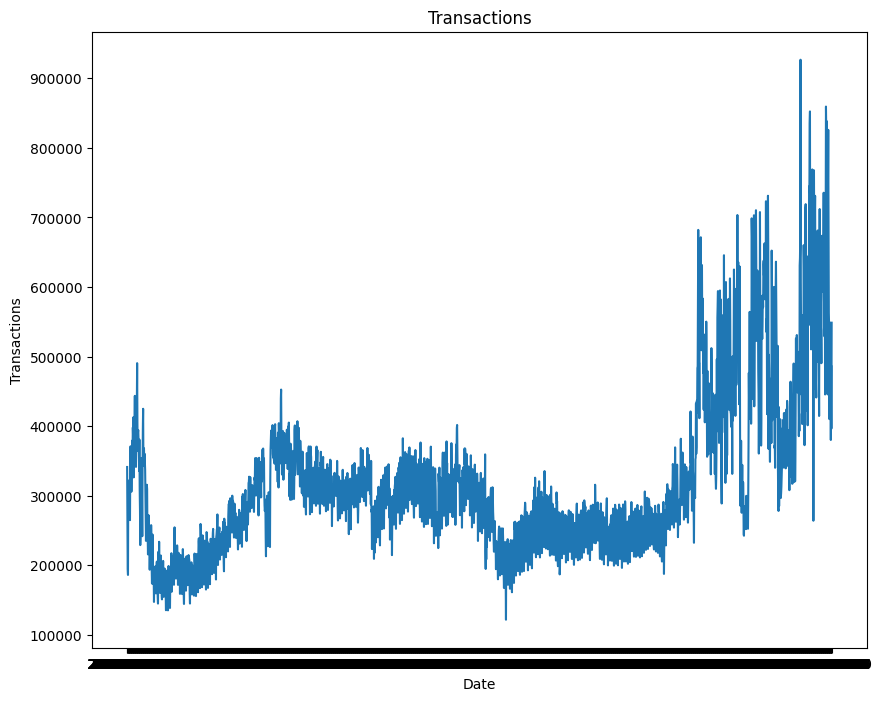

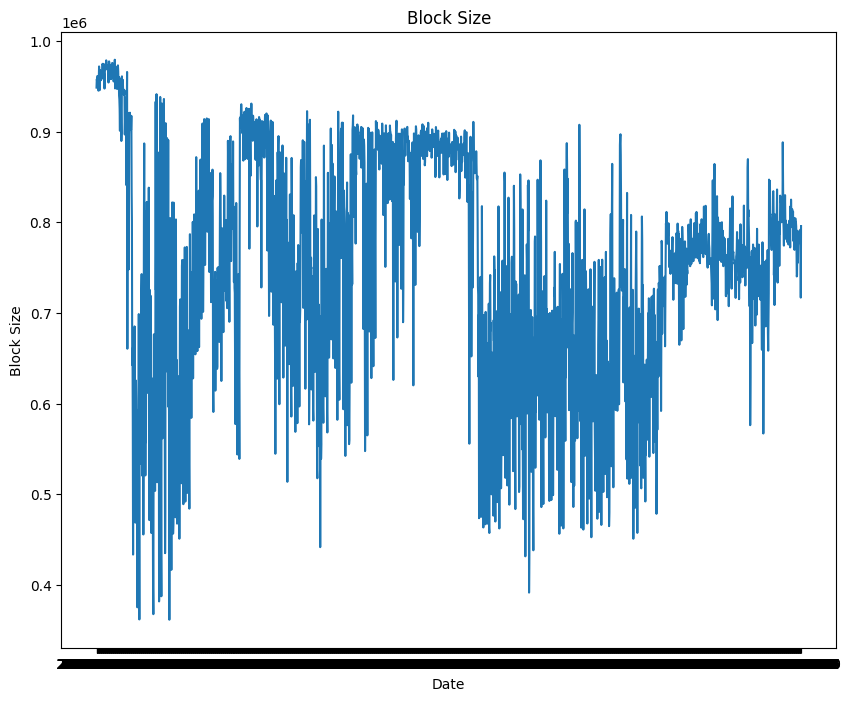

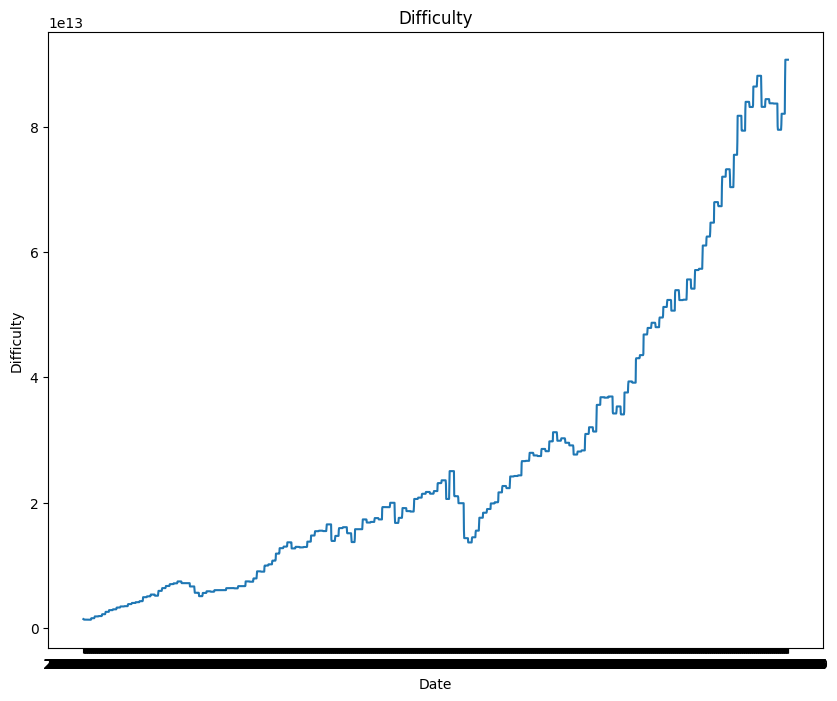

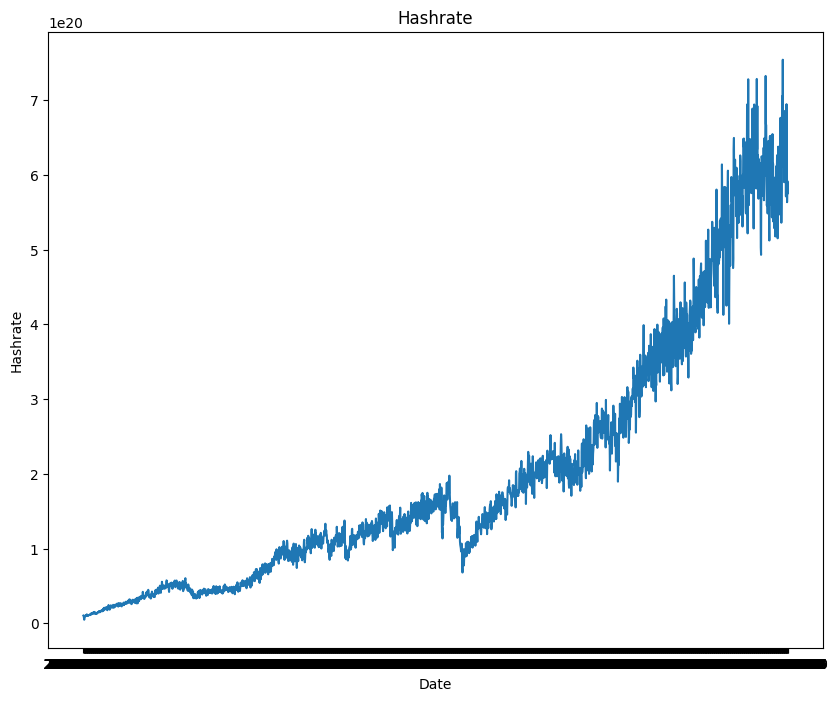

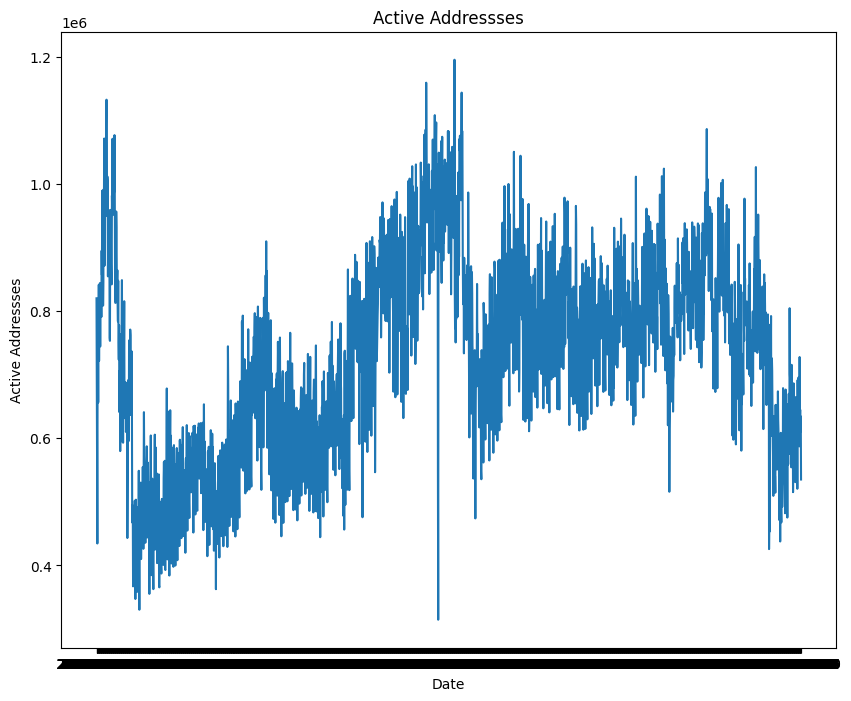

In [15]:
for i, column in enumerate(list(bicbtc.columns)):
    if i >=7:
        plotter.plot_lineplot(df=bicbtc, x="Date", y=column, title=column)
        plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\BTC\\bitinfocharts")

## LTC

### bitinfocharts

In [16]:
bic_ltc = pd.read_csv(f"{root_dir}\data\processed\LTC_data\LTC_bitinfocharts.csv")

In [87]:
bic_ltc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2422 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


In [88]:
bic_ltc.replace(np.nan, 0, inplace=True)

In [90]:
bic_ltc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2467 non-null   object 
 1   Open               2467 non-null   float64
 2   High               2467 non-null   float64
 3   Low                2467 non-null   float64
 4   Close              2467 non-null   float64
 5   Adj Close          2467 non-null   float64
 6   Volume             2467 non-null   int64  
 7   Transactions       2467 non-null   float64
 8   Block Size         2467 non-null   float64
 9   Difficulty         2467 non-null   float64
 10  Hashrate           2467 non-null   float64
 11  Active Addressses  2467 non-null   float64
dtypes: float64(10), int64(1), object(1)
memory usage: 231.4+ KB


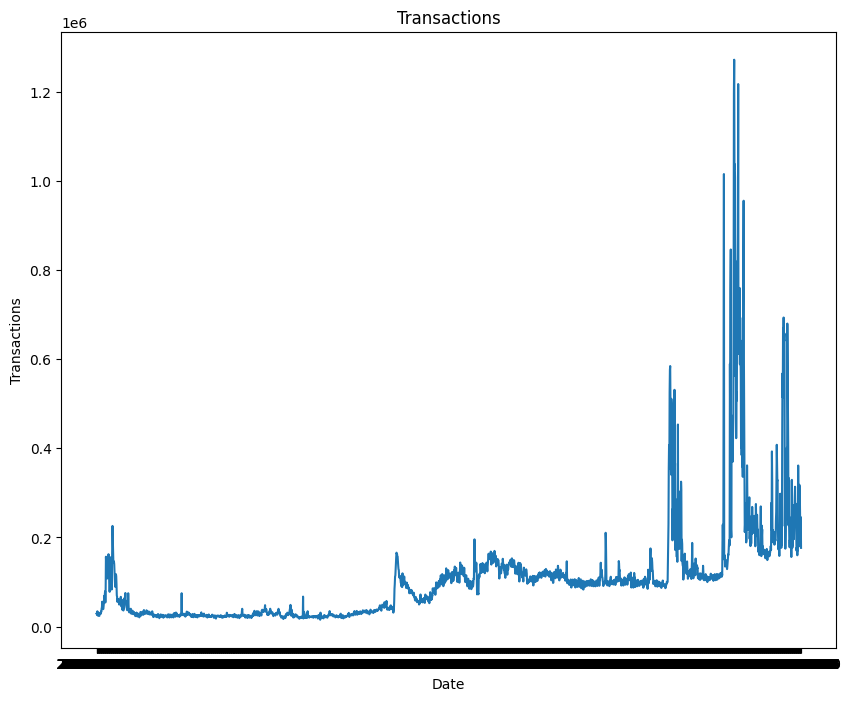

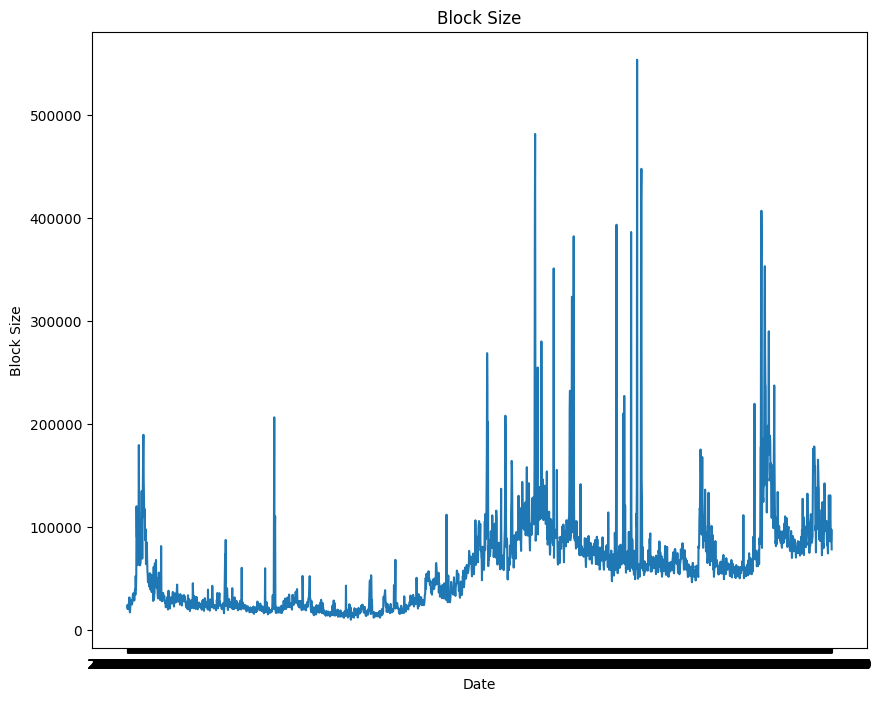

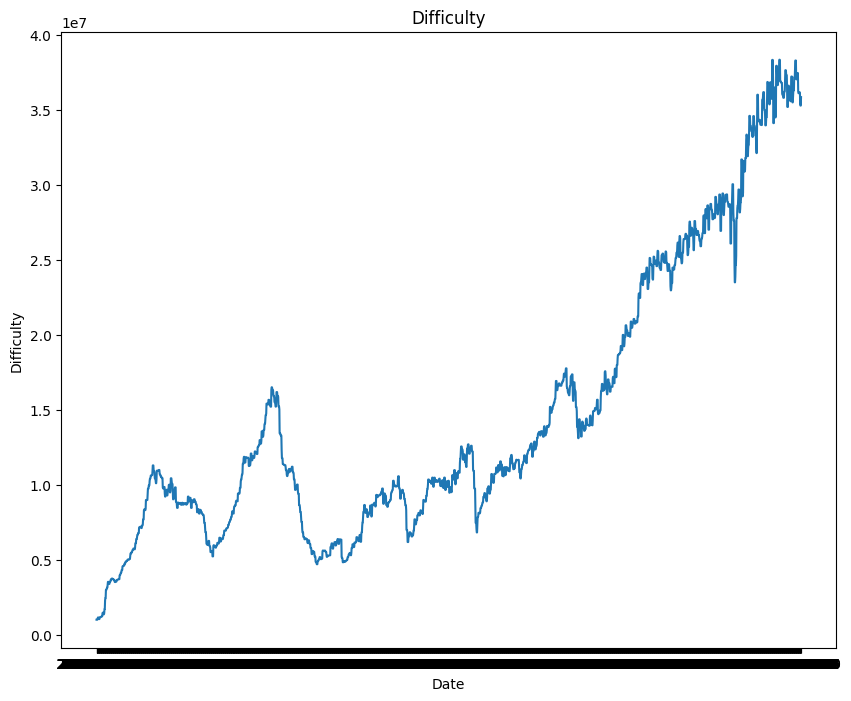

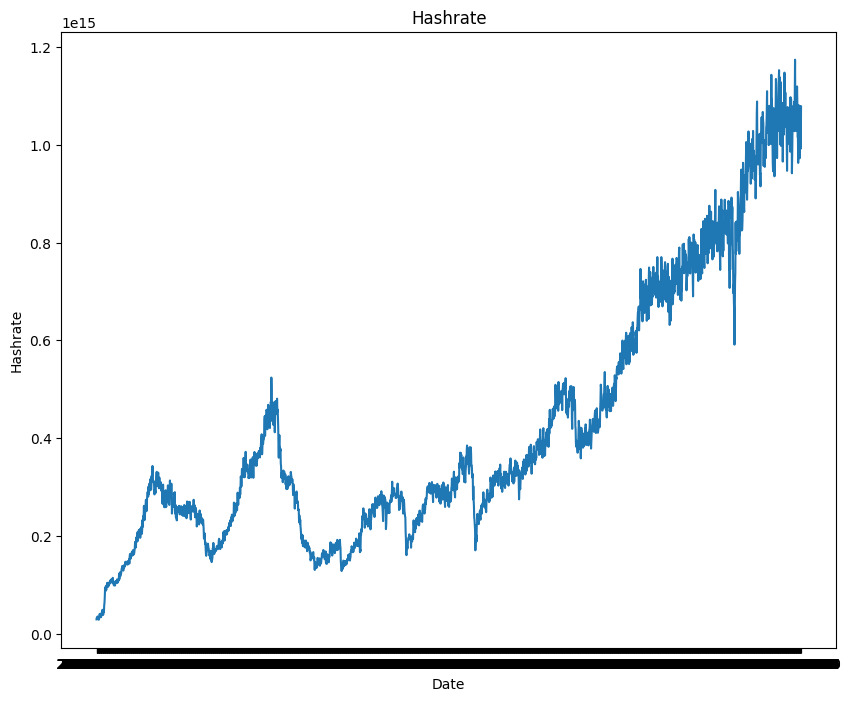

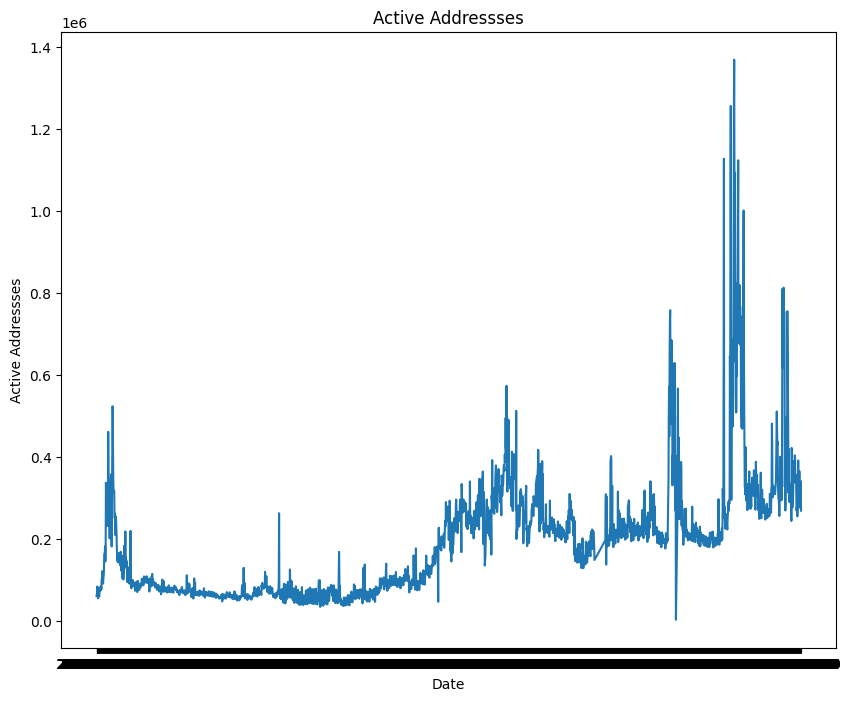

In [17]:
for i, column in enumerate(list(bic_ltc.columns)):
    if i >=7:
        plotter.plot_lineplot(df=bic_ltc, x="Date", y=column, title=column)
        plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\LTC\\bitinfocharts")

### oklink

In [18]:
ol_ltc = pd.read_csv(f"{root_dir}\data\processed\LTC_data\LTC_oklink.csv")

In [92]:
ol_ltc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 18 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   LTC total supply                                   2466 non-null   float64
 8   LTC market cap                                     2460 non-null   float64
 9   LTC aver

In [93]:
ol_ltc.replace(np.nan, 0, inplace=True)

In [94]:
ol_ltc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2467 entries, 0 to 2466
Data columns (total 18 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Date                                               2467 non-null   object 
 1   Open                                               2467 non-null   float64
 2   High                                               2467 non-null   float64
 3   Low                                                2467 non-null   float64
 4   Close                                              2467 non-null   float64
 5   Adj Close                                          2467 non-null   float64
 6   Volume                                             2467 non-null   int64  
 7   LTC total supply                                   2467 non-null   float64
 8   LTC market cap                                     2467 non-null   float64
 9   LTC aver

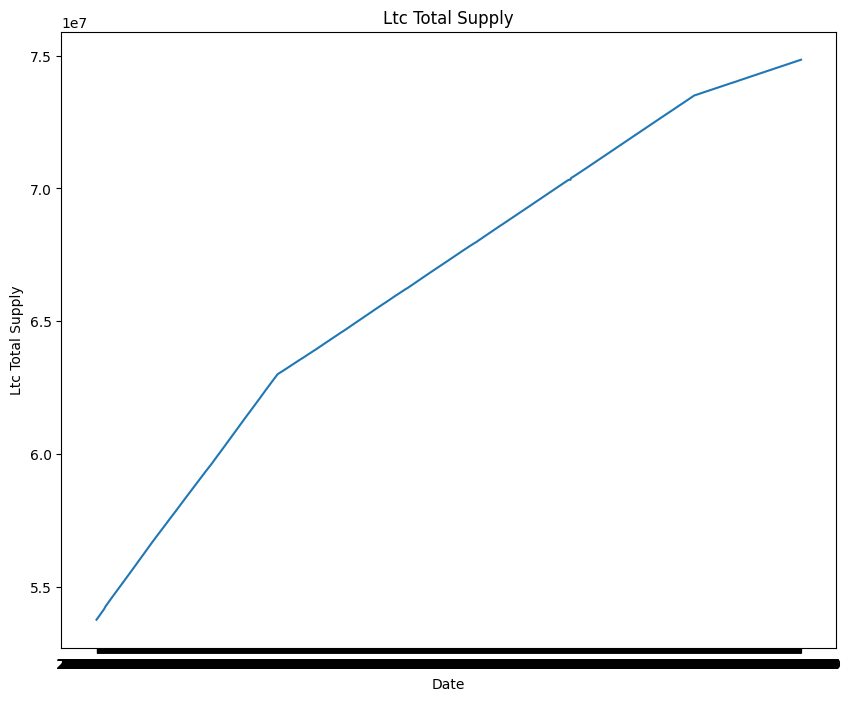

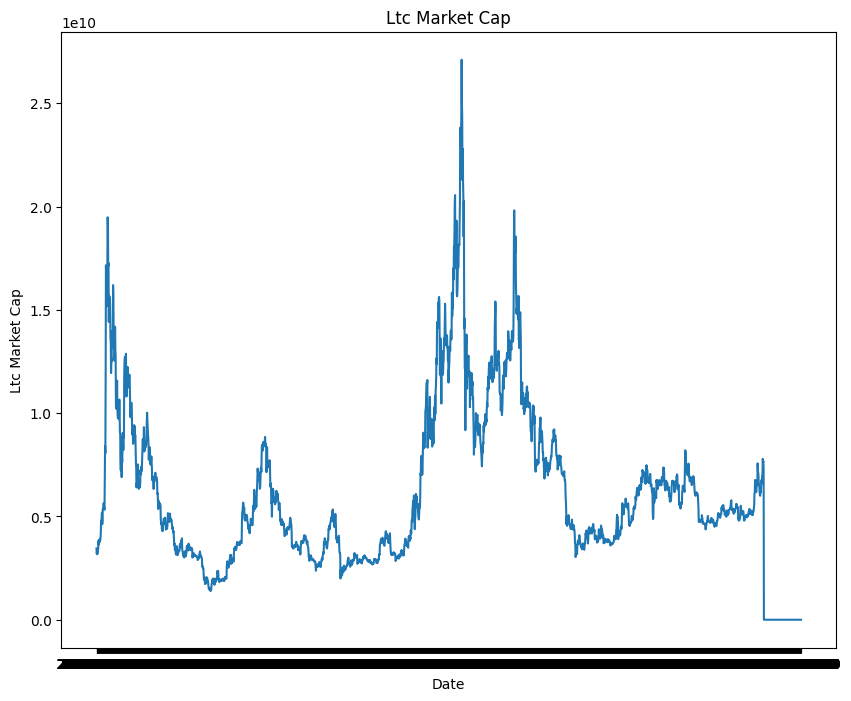

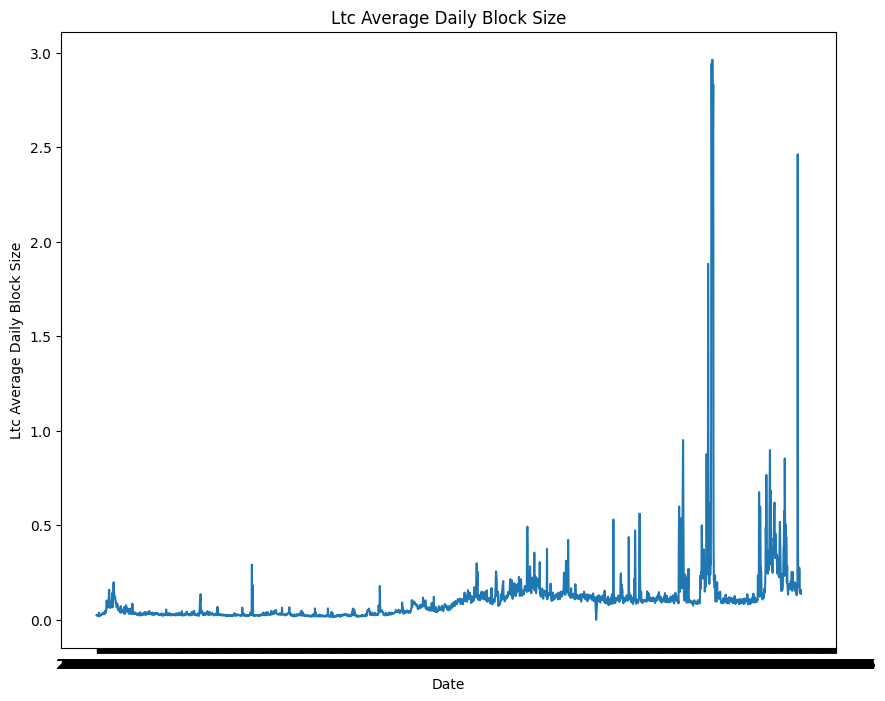

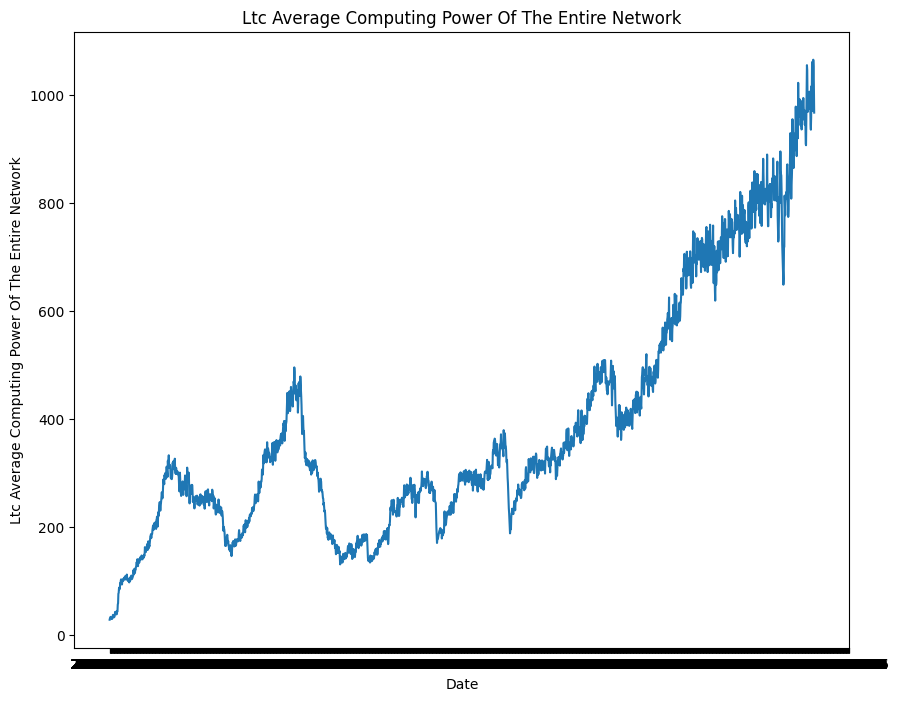

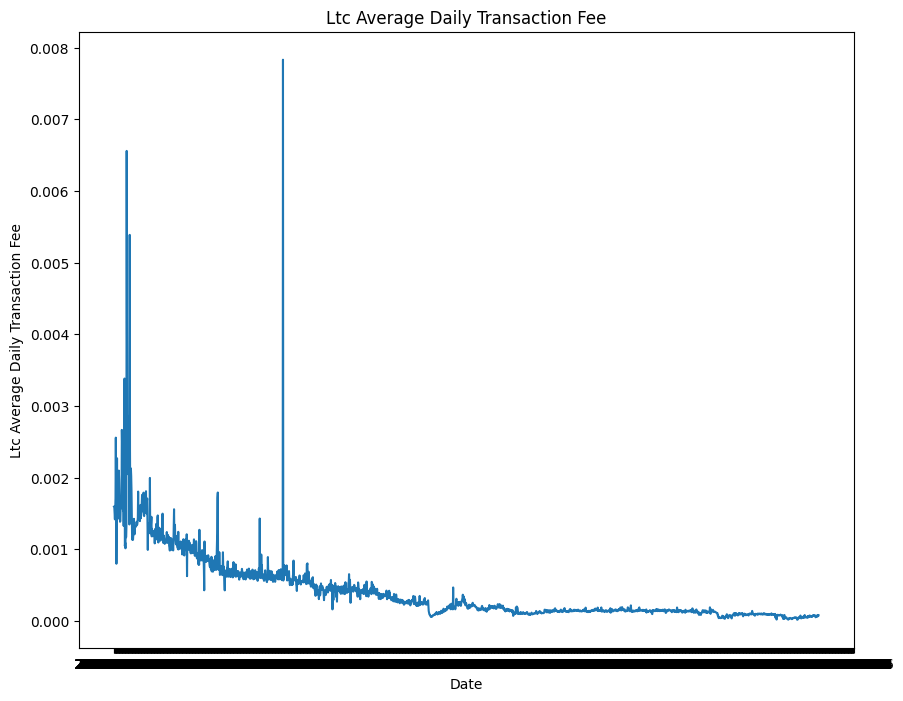

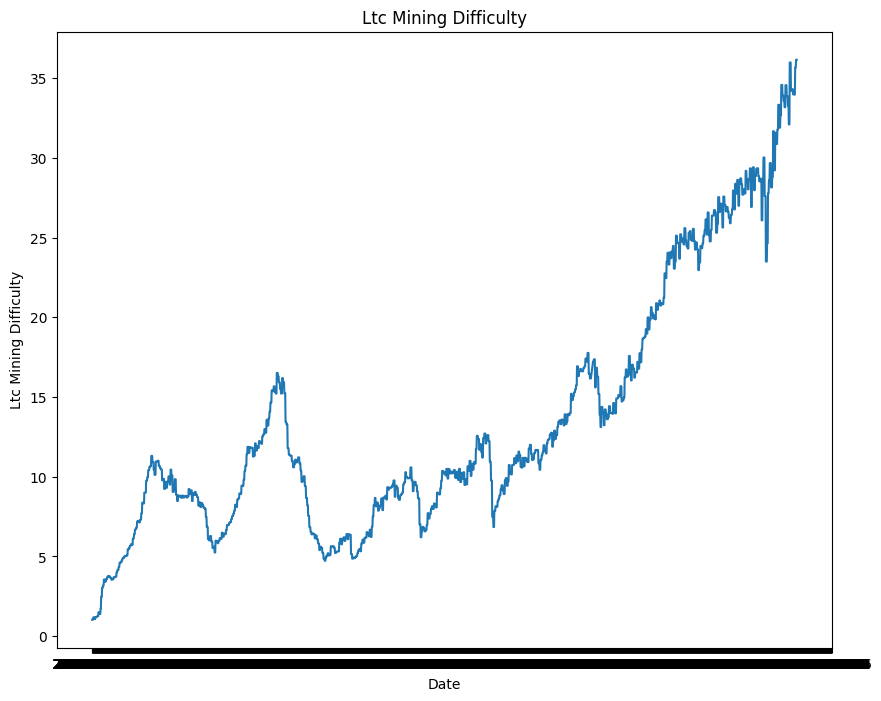

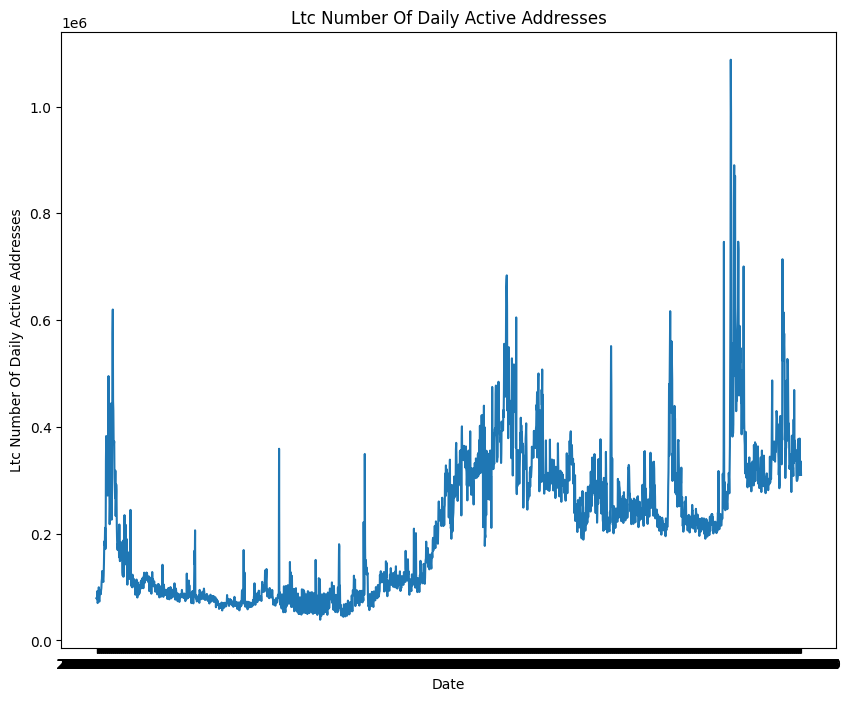

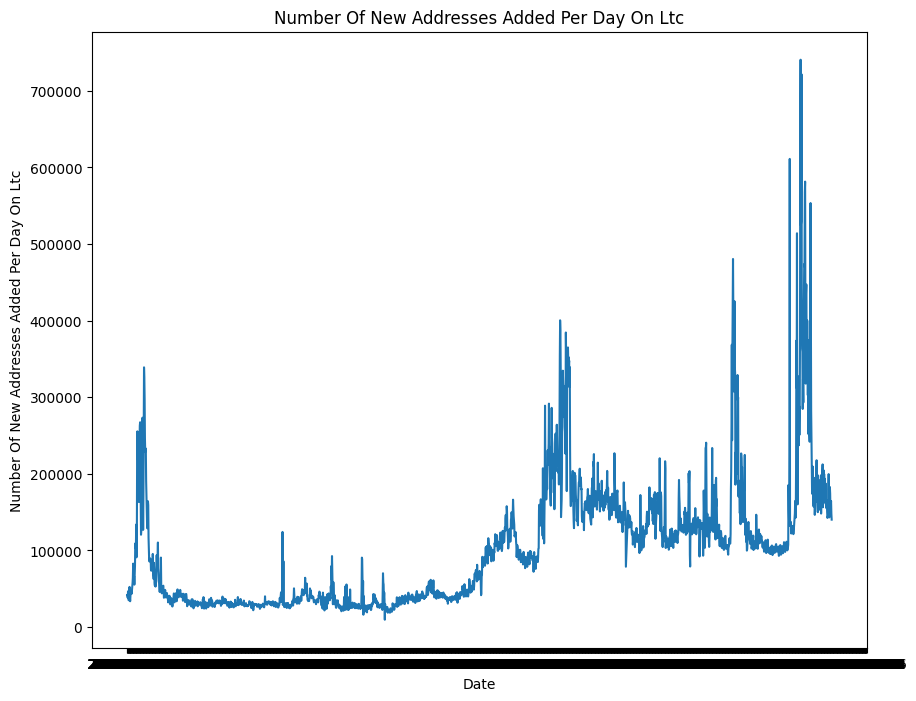

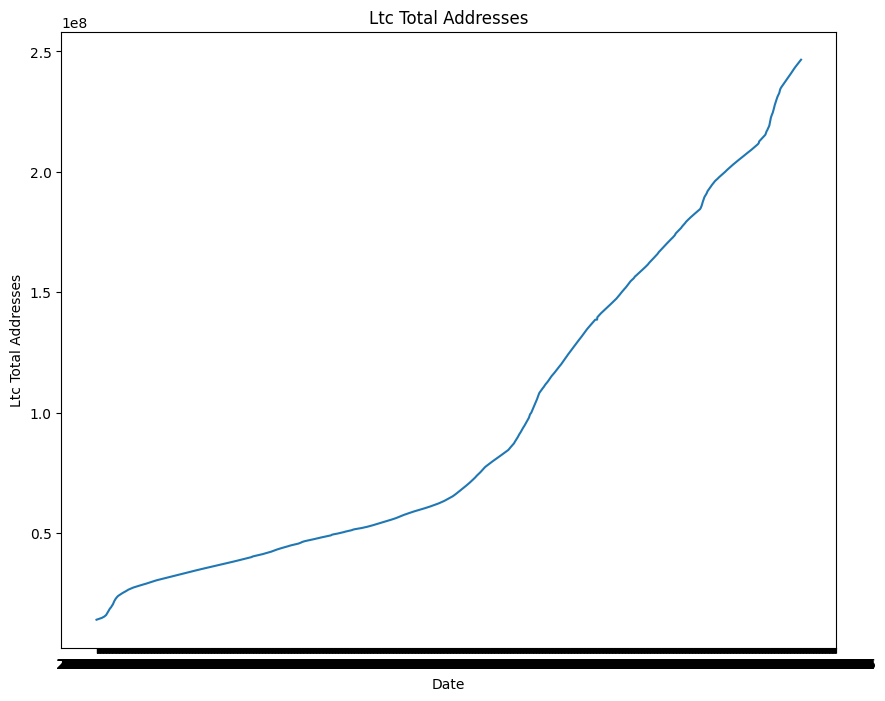

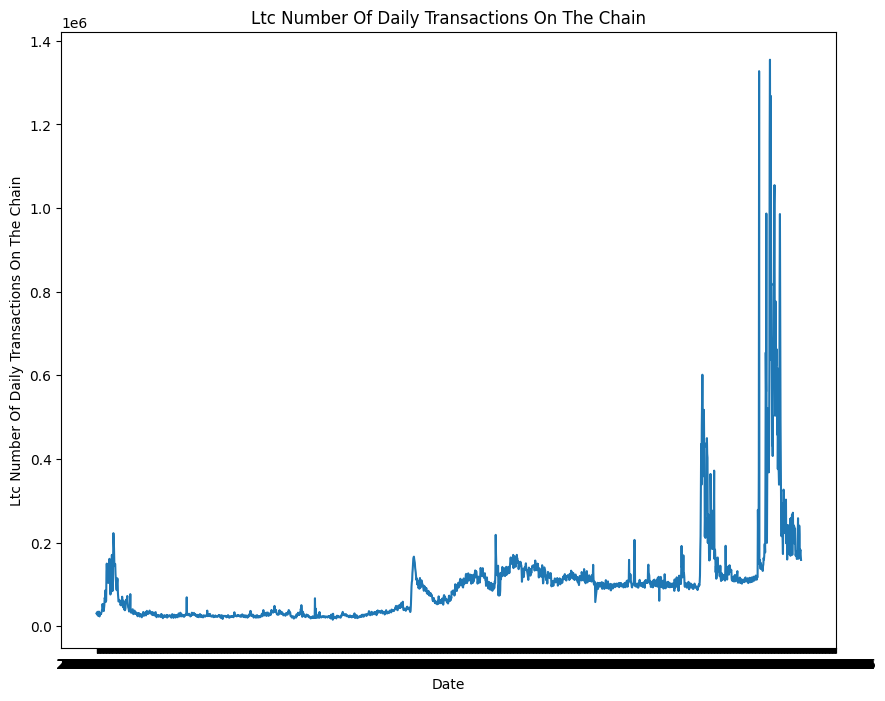

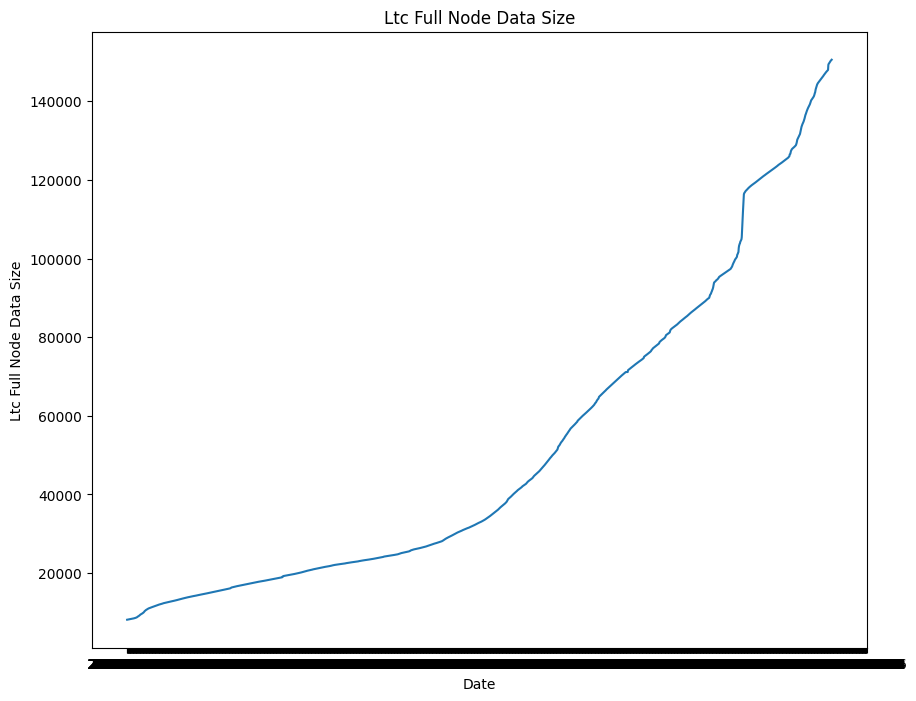

In [19]:
for i, column in enumerate(list(ol_ltc.columns)):
    if i >=7:
        plotter.plot_lineplot(df=ol_ltc, x="Date", y=column, title=column)
        plotter.save_graph(filepath=f"{root_dir}\\reports\\figures\\LTC\\oklink")

## Final Data Prep